<a href="https://colab.research.google.com/github/anfalear/notasestinferencial/blob/main/ANOVA_Clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES:
     Industria  Horas
0     Bancaria     12
1     Bancaria     10
2     Bancaria     10
3     Bancaria     12
4     Bancaria     10
5   Detallista      8
6   Detallista      8
7   Detallista      6
8   Detallista      8
9   Detallista     10
10  De seguros     10
11  De seguros      8
12  De seguros      6
13  De seguros      8
14  De seguros     10

Medias por Industria:
  Bancaria: 10.8000
  Detallista: 8.4000
  De seguros: 8.0000
Media Global: 9.0667

TABLA ANOVA DE UNA VÍA
Fuente de Variación            SC     gl           CM            F      Valor-p
--------------------------------------------------------------------------------
Entre Industrias          22.9333      2      11.4667       5.7333     0.017880
Error                     24.0000     12       2.0000
Total                     46.9333     14

INTERPRETACIÓN ANOVA (α = 0.05):
  F calculado = 5.7333
  F crítico = 3.8853
  Valor-p = 0.017880
  ✓ Hay diferencias significativas entre las medias de horas de u

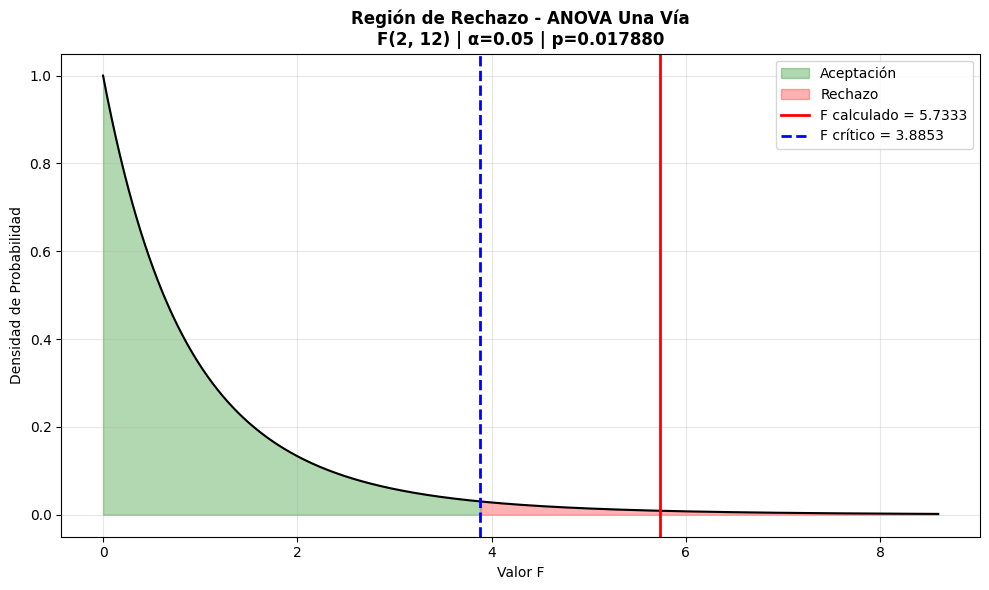

ANÁLISIS COMPLETO FINALIZADO


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

data = {
    'Industria': ['Bancaria'] * 5 + ['Detallista'] * 5 + ['De seguros'] * 5,
    'Horas': [12, 10, 10, 12, 10, 8, 8, 6, 8, 10, 10, 8, 6, 8, 10]
}

df = pd.DataFrame(data)
industrias = df['Industria'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Industria'] == i]['Horas'].values for i in industrias]
n_grupos = len(industrias)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Horas'].mean()
medias_industria = df.groupby('Industria')['Horas'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Industria:")
for i, industria in enumerate(industrias):
    print(f"  {industria}: {medias_industria[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Horas'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_industria[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(0.95, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Industrias':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

alpha = 0.05
print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de horas de uso de computadoras por industria.\n")
else:
    print("  ✗ No hay diferencias significativas entre las medias de horas de uso de computadoras por industria.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df['Horas'], groups=df['Industria'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)

DATOS ORIGINALES:
          Carretera 6  West End  Hickory St.  Ruta 59
Deans              18        17           21       22
Snaverly           16        23           23       22
Ormson             21        21           26       22
Zollaco            23        22           29       25
Filbeck            25        24           28       28


Media Global: 22.8000

Medias por Conductor:
  Deans: 19.5000
  Snaverly: 21.0000
  Ormson: 22.5000
  Zollaco: 24.7500
  Filbeck: 26.2500

Medias por Ruta:
  Carretera 6: 20.6000
  West End: 21.4000
  Hickory St.: 25.4000
  Ruta 59: 23.8000


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Conductores              119.7000      4      29.9250       9.7847     0.000934       3.2592
Rutas                     72.8000      3      24.2667       7.9346     0.003508       3.4903
Error    

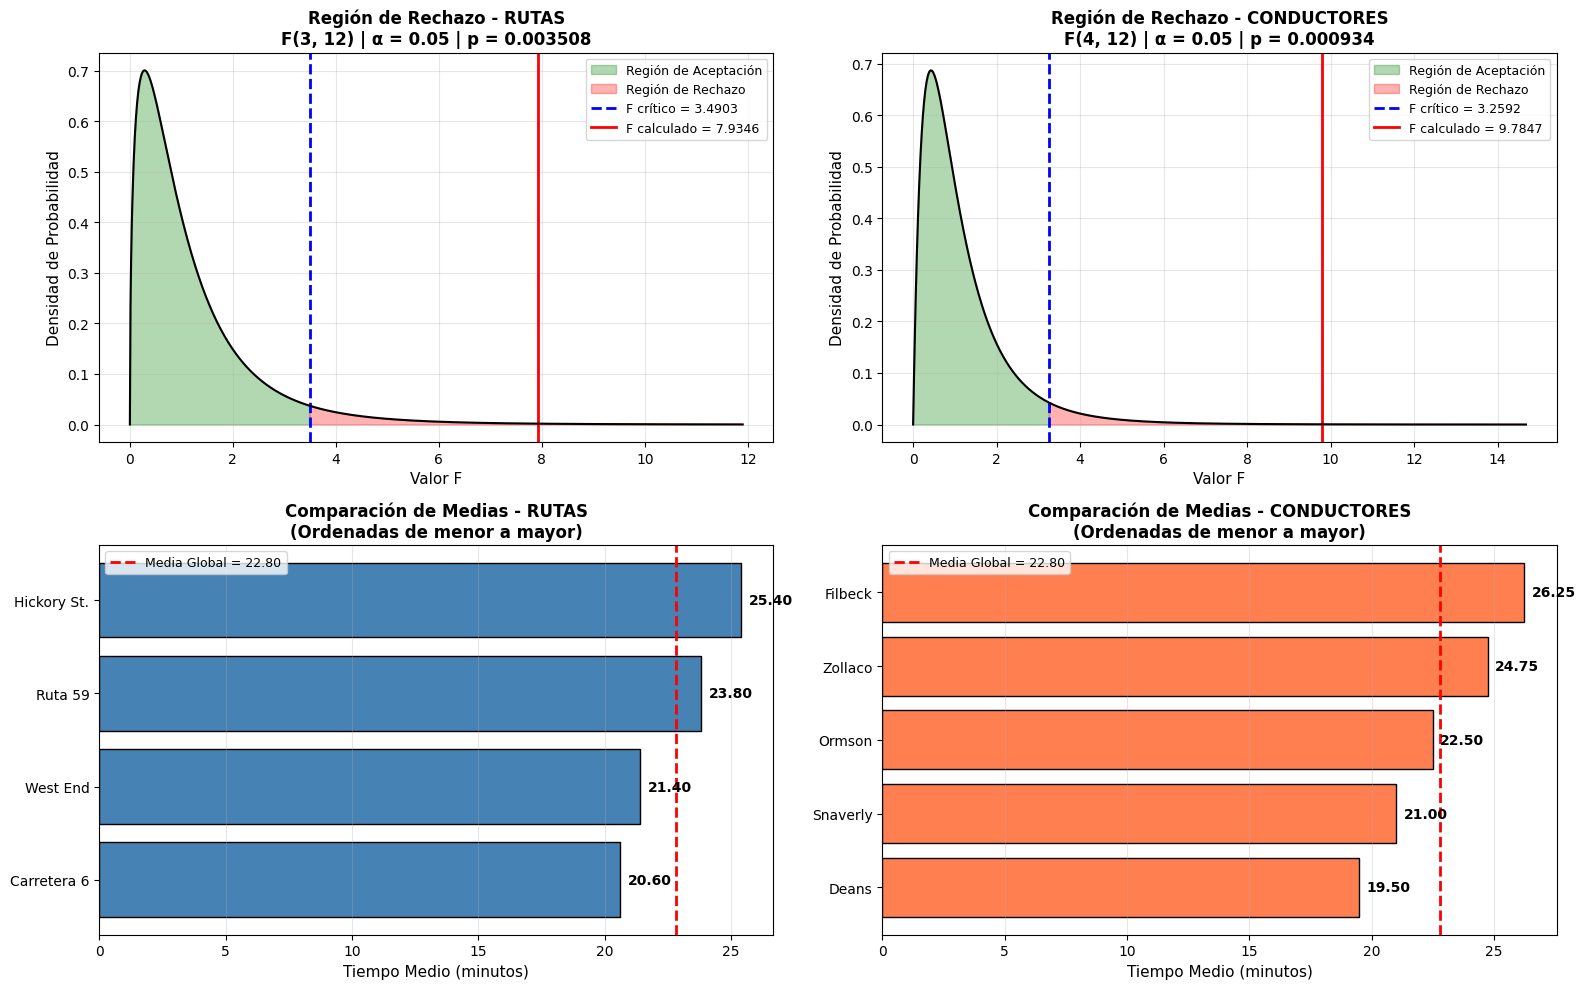

✓ Gráfico guardado como 'tukey_matrices_diferencias.png'


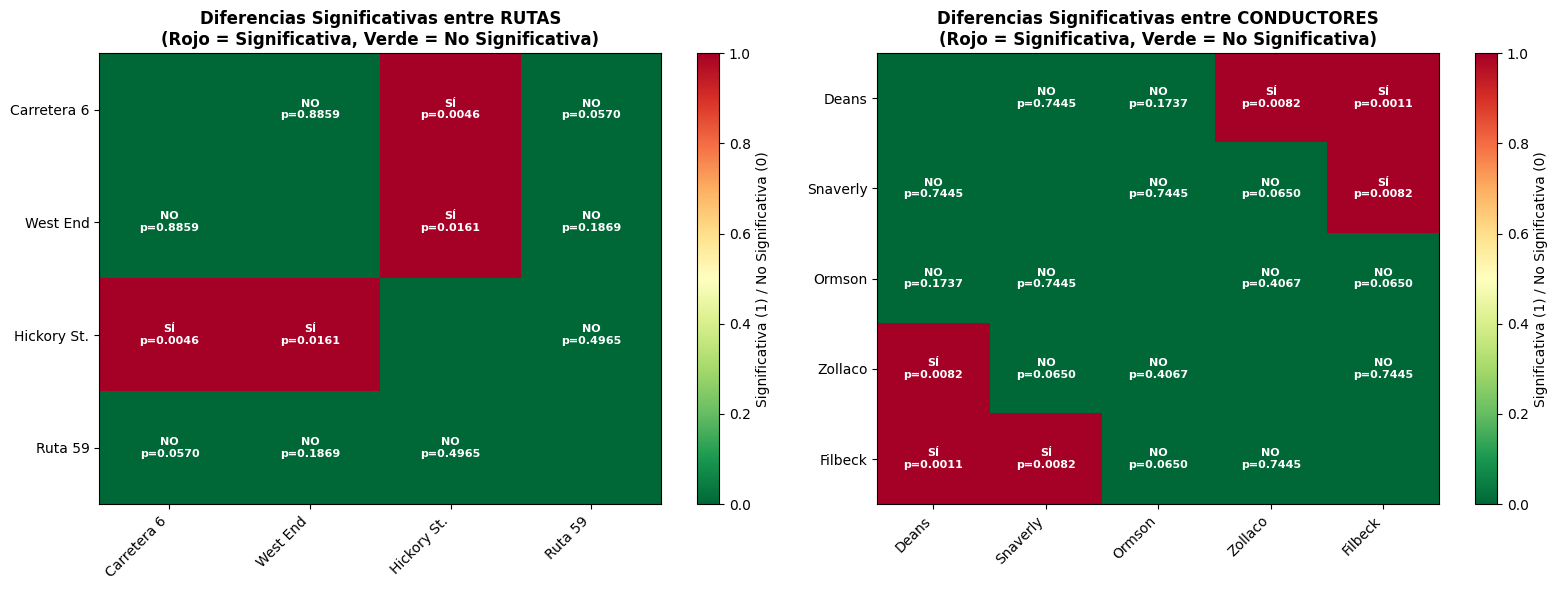


ANÁLISIS COMPLETO FINALIZADO


In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Datos del problema
conductores = ['Deans', 'Snaverly', 'Ormson', 'Zollaco', 'Filbeck']
rutas = ['Carretera 6', 'West End', 'Hickory St.', 'Ruta 59']

# Matriz de tiempos de recorrido
datos = np.array([
    [18, 17, 21, 22],  # Deans
    [16, 23, 23, 22],  # Snaverly
    [21, 21, 26, 22],  # Ormson
    [23, 22, 29, 25],  # Zollaco
    [25, 24, 28, 28]   # Filbeck
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=conductores, columns=rutas)
print("DATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# Preparar datos para ANOVA
n_conductores = len(conductores)
n_rutas = len(rutas)
n_total = n_conductores * n_rutas

# Calcular medias
media_global = np.mean(datos)
medias_conductores = np.mean(datos, axis=1)
medias_rutas = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f}")
print(f"\nMedias por Conductor:")
for i, cond in enumerate(conductores):
    print(f"  {cond}: {medias_conductores[i]:.4f}")
print(f"\nMedias por Ruta:")
for i, ruta in enumerate(rutas):
    print(f"  {ruta}: {medias_rutas[i]:.4f}")
print("\n" + "="*80 + "\n")

# ============================================================================
# ANOVA DE DOS VÍAS SIN INTERACCIÓN
# ============================================================================

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de conductores (SCC)
SCC = n_rutas * np.sum((medias_conductores - media_global)**2)

# Suma de cuadrados de rutas (SCR)
SCR = n_conductores * np.sum((medias_rutas - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCC - SCR

# Grados de libertad
gl_conductores = n_conductores - 1
gl_rutas = n_rutas - 1
gl_error = (n_conductores - 1) * (n_rutas - 1)
gl_total = n_total - 1

# Cuadrados medios
CMC = SCC / gl_conductores
CMR = SCR / gl_rutas
CME = SCE / gl_error

# Estadísticos F
F_conductores = CMC / CME
F_rutas = CMR / CME

# Valores p
p_conductores = 1 - stats.f.cdf(F_conductores, gl_conductores, gl_error)
p_rutas = 1 - stats.f.cdf(F_rutas, gl_rutas, gl_error)

# Valores críticos F para α = 0.05
F_crit_conductores = stats.f.ppf(0.95, gl_conductores, gl_error)
F_crit_rutas = stats.f.ppf(0.95, gl_rutas, gl_error)

# Crear tabla ANOVA
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Conductores':<20} {SCC:>12.4f} {gl_conductores:>6} {CMC:>12.4f} {F_conductores:>12.4f} {p_conductores:>12.6f} {F_crit_conductores:>12.4f}")
print(f"{'Rutas':<20} {SCR:>12.4f} {gl_rutas:>6} {CMR:>12.4f} {F_rutas:>12.4f} {p_rutas:>12.6f} {F_crit_rutas:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# Interpretación de resultados
alpha = 0.05
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE CONDUCTORES:")
print(f"   F calculado = {F_conductores:.4f}")
print(f"   F crítico   = {F_crit_conductores:.4f}")
print(f"   Valor-p     = {p_conductores:.6f}")
if p_conductores < alpha:
    print(f"   ✓ Hay diferencia significativa entre conductores (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre conductores (p ≥ {alpha})")

print(f"\n2. EFECTO DE RUTAS:")
print(f"   F calculado = {F_rutas:.4f}")
print(f"   F crítico   = {F_crit_rutas:.4f}")
print(f"   Valor-p     = {p_rutas:.6f}")
if p_rutas < alpha:
    print(f"   ✓ Hay diferencia significativa entre rutas (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre rutas (p ≥ {alpha})")

print("\n" + "="*80)
print("\nRESPUESTA A LAS PREGUNTAS:")
print("-" * 80)
print("\n¿Hay diferencia entre los tiempos medios de las cuatro rutas?")
if p_rutas < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_rutas:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_rutas:.6f} ≥ 0.05)")

print("\n¿Hay diferencia entre los tiempos medios de los conductores?")
print("(eliminando el efecto de las rutas)")
if p_conductores < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_conductores:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_conductores:.6f} ≥ 0.05)")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD)")
print("="*80)

# --------------------------------------------------------------------------
# COMPARACIONES PARA RUTAS
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA RUTAS:")
print("-"*80)

q_rutas = stats.studentized_range.ppf(0.95, n_rutas, gl_error)
HSD_rutas = q_rutas * np.sqrt(CME / n_conductores)

print(f"\nValor crítico q (α=0.05, k={n_rutas}, gl_error={gl_error}): {q_rutas:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_rutas:.4f}")
print(f"\n{'Ruta i':<15} {'Ruta j':<15} {'Media i':>10} {'Media j':>10} "
      f"{'Diferencia':>12} {'|Dif|':>10} {'q_obs':>8} {'p-valor':>10} {'Significativa':>15}")
print("-"*115)

comparaciones_rutas = []
for i, j in combinations(range(n_rutas), 2):
    diff    = medias_rutas[i] - medias_rutas[j]
    abs_diff = abs(diff)
    q_obs   = abs_diff / np.sqrt(CME / n_conductores)
    p_val   = stats.studentized_range.sf(q_obs, n_rutas, gl_error)
    es_sig  = "SÍ" if abs_diff > HSD_rutas else "NO"
    comparaciones_rutas.append({
        'Ruta_i': rutas[i], 'Ruta_j': rutas[j],
        'Media_i': medias_rutas[i], 'Media_j': medias_rutas[j],
        'Diferencia': diff, 'Abs_Diferencia': abs_diff,
        'q_obs': q_obs, 'p_valor': p_val, 'Significativa': es_sig
    })
    print(f"{rutas[i]:<15} {rutas[j]:<15} {medias_rutas[i]:>10.4f} {medias_rutas[j]:>10.4f} "
          f"{diff:>12.4f} {abs_diff:>10.4f} {q_obs:>8.4f} {p_val:>10.6f} {es_sig:>15}")

# --------------------------------------------------------------------------
# COMPARACIONES PARA CONDUCTORES
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA CONDUCTORES:")
print("-"*80)

q_conductores = stats.studentized_range.ppf(0.95, n_conductores, gl_error)
HSD_conductores = q_conductores * np.sqrt(CME / n_rutas)

print(f"\nValor crítico q (α=0.05, k={n_conductores}, gl_error={gl_error}): {q_conductores:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_conductores:.4f}")
print(f"\n{'Conductor i':<15} {'Conductor j':<15} {'Media i':>10} {'Media j':>10} "
      f"{'Diferencia':>12} {'|Dif|':>10} {'q_obs':>8} {'p-valor':>10} {'Significativa':>15}")
print("-"*115)

comparaciones_conductores = []
for i, j in combinations(range(n_conductores), 2):
    diff    = medias_conductores[i] - medias_conductores[j]
    abs_diff = abs(diff)
    q_obs   = abs_diff / np.sqrt(CME / n_rutas)
    p_val   = stats.studentized_range.sf(q_obs, n_conductores, gl_error)
    es_sig  = "SÍ" if abs_diff > HSD_conductores else "NO"
    comparaciones_conductores.append({
        'Conductor_i': conductores[i], 'Conductor_j': conductores[j],
        'Media_i': medias_conductores[i], 'Media_j': medias_conductores[j],
        'Diferencia': diff, 'Abs_Diferencia': abs_diff,
        'q_obs': q_obs, 'p_valor': p_val, 'Significativa': es_sig
    })
    print(f"{conductores[i]:<15} {conductores[j]:<15} {medias_conductores[i]:>10.4f} {medias_conductores[j]:>10.4f} "
          f"{diff:>12.4f} {abs_diff:>10.4f} {q_obs:>8.4f} {p_val:>10.6f} {es_sig:>15}")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# --- Gráfico 1: Región de rechazo para RUTAS ---
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_rutas, F_crit_rutas) * 1.5, 1000)
y = stats.f.pdf(x, gl_rutas, gl_error)

x_accept = x[x <= F_crit_rutas]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_rutas, gl_error),
                 alpha=0.3, color='green', label='Región de Aceptación')
x_reject = x[x >= F_crit_rutas]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_rutas, gl_error),
                 alpha=0.3, color='red', label='Región de Rechazo')
ax1.axvline(F_crit_rutas, color='blue', linestyle='--', linewidth=2,
            label=f'F crítico = {F_crit_rutas:.4f}')
ax1.axvline(F_rutas, color='red', linestyle='-', linewidth=2,
            label=f'F calculado = {F_rutas:.4f}')
ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax1.set_title(f'Región de Rechazo - RUTAS\nF({gl_rutas}, {gl_error}) | α = 0.05 | p = {p_rutas:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Región de rechazo para CONDUCTORES ---
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_conductores, F_crit_conductores) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_conductores, gl_error)

x_accept2 = x2[x2 <= F_crit_conductores]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_conductores, gl_error),
                 alpha=0.3, color='green', label='Región de Aceptación')
x_reject2 = x2[x2 >= F_crit_conductores]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_conductores, gl_error),
                 alpha=0.3, color='red', label='Región de Rechazo')
ax2.axvline(F_crit_conductores, color='blue', linestyle='--', linewidth=2,
            label=f'F crítico = {F_crit_conductores:.4f}')
ax2.axvline(F_conductores, color='red', linestyle='-', linewidth=2,
            label=f'F calculado = {F_conductores:.4f}')
ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11)
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax2.set_title(f'Región de Rechazo - CONDUCTORES\nF({gl_conductores}, {gl_error}) | α = 0.05 | p = {p_conductores:.6f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Medias por RUTAS ---
ax3 = plt.subplot(2, 2, 3)
rutas_ordenadas = sorted(range(n_rutas), key=lambda i: medias_rutas[i])
medias_ord_rutas = [medias_rutas[i] for i in rutas_ordenadas]
nombres_ord_rutas = [rutas[i] for i in rutas_ordenadas]

bars3 = ax3.barh(nombres_ord_rutas, medias_ord_rutas, color='steelblue', edgecolor='black')
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2,
            label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Tiempo Medio (minutos)', fontsize=11)
ax3.set_title('Comparación de Medias - RUTAS\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars3, medias_ord_rutas):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# --- Gráfico 4: Medias por CONDUCTORES ---
ax4 = plt.subplot(2, 2, 4)
cond_ordenados = sorted(range(n_conductores), key=lambda i: medias_conductores[i])
medias_ord_cond = [medias_conductores[i] for i in cond_ordenados]
nombres_ord_cond = [conductores[i] for i in cond_ordenados]

bars4 = ax4.barh(nombres_ord_cond, medias_ord_cond, color='coral', edgecolor='black')
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2,
            label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Tiempo Medio (minutos)', fontsize=11)
ax4.set_title('Comparación de Medias - CONDUCTORES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars4, medias_ord_cond):
    ax4.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('anova_dos_vias_analisis.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'anova_dos_vias_analisis.png'")
plt.show()

# ============================================================================
# MATRICES DE DIFERENCIAS SIGNIFICATIVAS (Tukey)
# ============================================================================

fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# --- Matriz RUTAS ---
diff_matrix_rutas = np.zeros((n_rutas, n_rutas))
for i in range(n_rutas):
    for j in range(n_rutas):
        if i != j:
            diff = abs(medias_rutas[i] - medias_rutas[j])
            diff_matrix_rutas[i, j] = 1 if diff > HSD_rutas else 0

im1 = ax5.imshow(diff_matrix_rutas, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_rutas))
ax5.set_yticks(range(n_rutas))
ax5.set_xticklabels(rutas, rotation=45, ha='right')
ax5.set_yticklabels(rutas)
ax5.set_title('Diferencias Significativas entre RUTAS\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')
for i in range(n_rutas):
    for j in range(n_rutas):
        if i != j:
            # Mostrar valor p de Tukey dentro de la celda
            q_ij  = abs(medias_rutas[i] - medias_rutas[j]) / np.sqrt(CME / n_conductores)
            p_ij  = stats.studentized_range.sf(q_ij, n_rutas, gl_error)
            label = f"{'SÍ' if diff_matrix_rutas[i,j]==1 else 'NO'}\np={p_ij:.4f}"
            ax5.text(j, i, label, ha='center', va='center',
                     color='white', fontweight='bold', fontsize=8)
plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# --- Matriz CONDUCTORES ---
diff_matrix_cond = np.zeros((n_conductores, n_conductores))
for i in range(n_conductores):
    for j in range(n_conductores):
        if i != j:
            diff = abs(medias_conductores[i] - medias_conductores[j])
            diff_matrix_cond[i, j] = 1 if diff > HSD_conductores else 0

im2 = ax6.imshow(diff_matrix_cond, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_conductores))
ax6.set_yticks(range(n_conductores))
ax6.set_xticklabels(conductores, rotation=45, ha='right')
ax6.set_yticklabels(conductores)
ax6.set_title('Diferencias Significativas entre CONDUCTORES\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')
for i in range(n_conductores):
    for j in range(n_conductores):
        if i != j:
            # Mostrar valor p de Tukey dentro de la celda
            q_ij  = abs(medias_conductores[i] - medias_conductores[j]) / np.sqrt(CME / n_rutas)
            p_ij  = stats.studentized_range.sf(q_ij, n_conductores, gl_error)
            label = f"{'SÍ' if diff_matrix_cond[i,j]==1 else 'NO'}\np={p_ij:.4f}"
            ax6.text(j, i, label, ha='center', va='center',
                     color='white', fontweight='bold', fontsize=8)
plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('tukey_matrices_diferencias.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'tukey_matrices_diferencias.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)

PROBLEMA: CIRUGÍAS EN HOSPITALES DE TULSA, OKLAHOMA

DATOS ORIGINALES:
           St. Luke's  St. Vincent  Mercy
Lunes              14           18     24
Martes             20           24     14
Miércoles          16           22     14
Jueves             18           20     22
Viernes            20           28     24


Media Global: 19.8667 cirugías

Medias por Día de la Semana:
  Lunes.......  18.6667 cirugías
  Martes......  19.3333 cirugías
  Miércoles...  17.3333 cirugías
  Jueves......  20.0000 cirugías
  Viernes.....  24.0000 cirugías

Medias por Hospital:
  St. Luke's.....  17.6000 cirugías
  St. Vincent....  22.4000 cirugías
  Mercy..........  19.6000 cirugías


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Días de la Semana         75.7333      4      18.9333       1.2851     0.352359       3.8379
Hospit

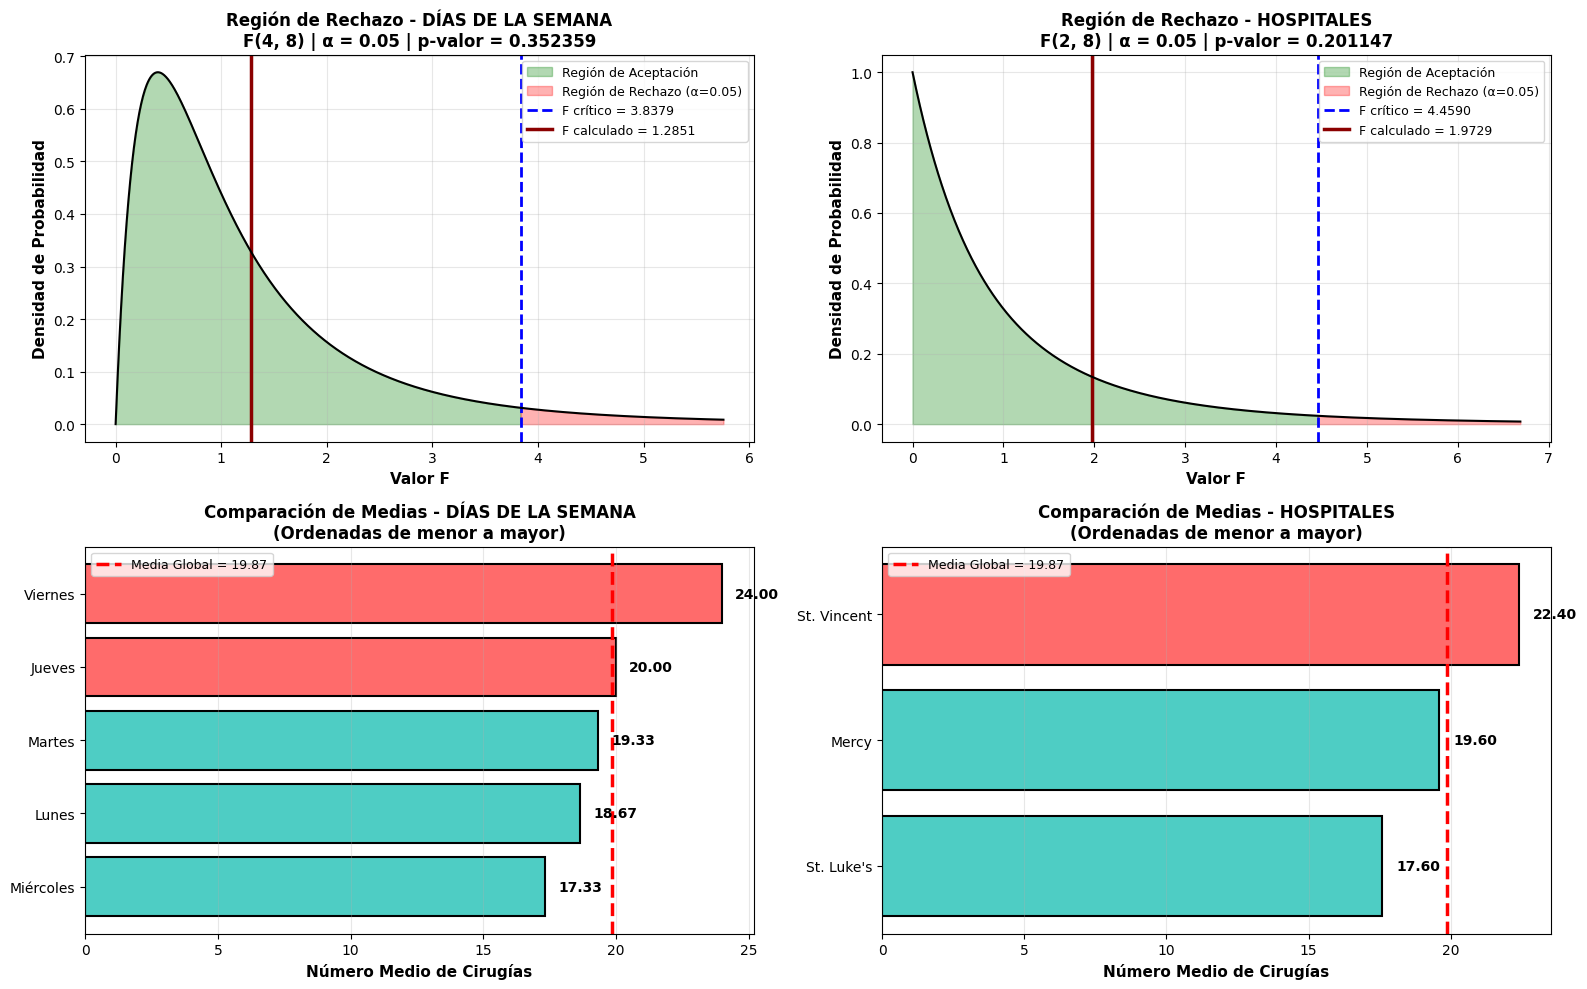

✓ Gráfico guardado como 'cirugias_tukey_matrices.png'


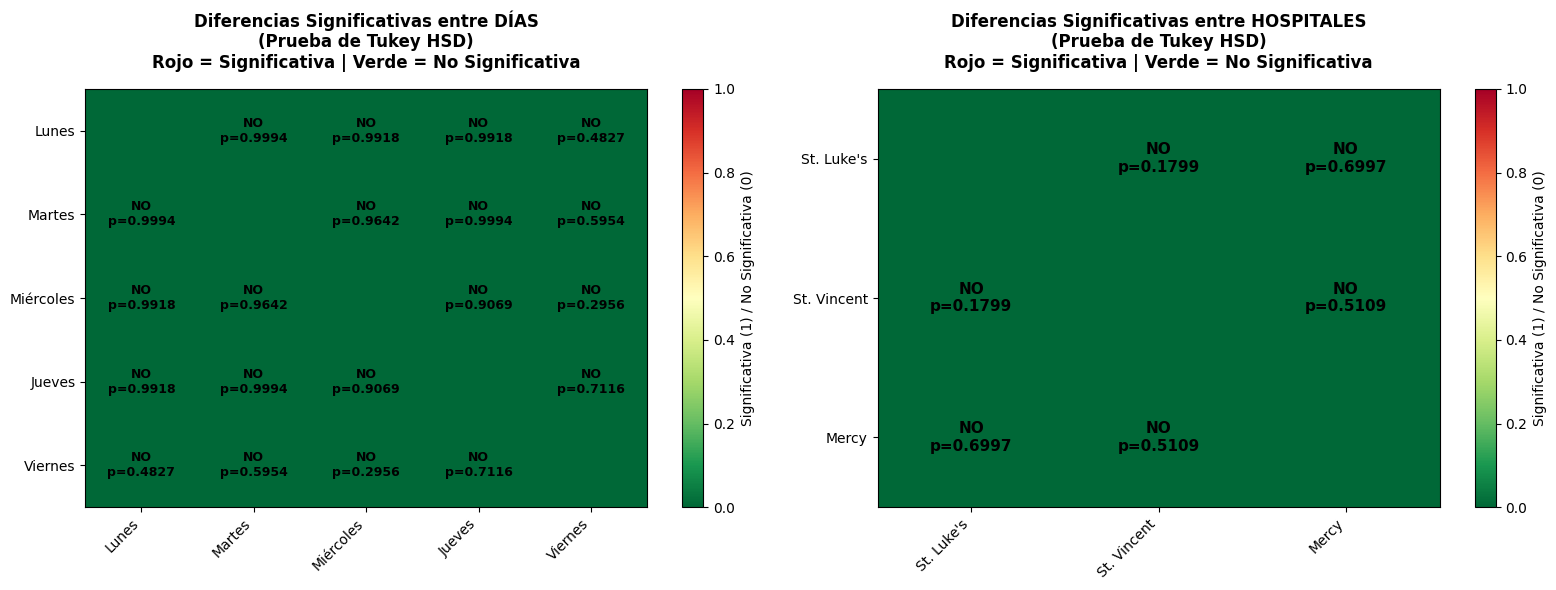


ANÁLISIS COMPLETO FINALIZADO

CONCLUSIÓN FINAL:
--------------------------------------------------------------------------------
✗ No se encontraron diferencias significativas ni por hospital ni por día.


In [10]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Configuración para mejor visualización
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================
# Datos del problema - Hospitales de Tulsa, Oklahoma
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
hospitales = ["St. Luke's", "St. Vincent", "Mercy"]

# Matriz de número de cirugías realizadas
datos = np.array([
    [14, 18, 24],  # Lunes
    [20, 24, 14],  # Martes
    [16, 22, 14],  # Miércoles
    [18, 20, 22],  # Jueves
    [20, 28, 24]   # Viernes
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=dias, columns=hospitales)
print("="*80)
print("PROBLEMA: CIRUGÍAS EN HOSPITALES DE TULSA, OKLAHOMA")
print("="*80)
print("\nDATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

n_dias = len(dias)
n_hospitales = len(hospitales)
n_total = n_dias * n_hospitales

# Calcular medias
media_global = np.mean(datos)
medias_dias = np.mean(datos, axis=1)
medias_hospitales = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f} cirugías")
print(f"\nMedias por Día de la Semana:")
for i, dia in enumerate(dias):
    print(f"  {dia:.<12} {medias_dias[i]:>8.4f} cirugías")
print(f"\nMedias por Hospital:")
for i, hosp in enumerate(hospitales):
    print(f"  {hosp:.<15} {medias_hospitales[i]:>8.4f} cirugías")
print("\n" + "="*80 + "\n")

# ============================================================================
# ANOVA DE DOS VÍAS SIN INTERACCIÓN
# ============================================================================

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de días (SCD)
SCD = n_hospitales * np.sum((medias_dias - media_global)**2)

# Suma de cuadrados de hospitales (SCH)
SCH = n_dias * np.sum((medias_hospitales - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCD - SCH

# Grados de libertad
gl_dias = n_dias - 1
gl_hospitales = n_hospitales - 1
gl_error = (n_dias - 1) * (n_hospitales - 1)
gl_total = n_total - 1

# Cuadrados medios
CMD = SCD / gl_dias
CMH = SCH / gl_hospitales
CME = SCE / gl_error

# Estadísticos F
F_dias = CMD / CME
F_hospitales = CMH / CME

# Valores p
p_dias = 1 - stats.f.cdf(F_dias, gl_dias, gl_error)
p_hospitales = 1 - stats.f.cdf(F_hospitales, gl_hospitales, gl_error)

# Valores críticos F para α = 0.05
F_crit_dias = stats.f.ppf(0.95, gl_dias, gl_error)
F_crit_hospitales = stats.f.ppf(0.95, gl_hospitales, gl_error)

# ============================================================================
# TABLA ANOVA
# ============================================================================
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Días de la Semana':<20} {SCD:>12.4f} {gl_dias:>6} {CMD:>12.4f} {F_dias:>12.4f} {p_dias:>12.6f} {F_crit_dias:>12.4f}")
print(f"{'Hospitales':<20} {SCH:>12.4f} {gl_hospitales:>6} {CMH:>12.4f} {F_hospitales:>12.4f} {p_hospitales:>12.6f} {F_crit_hospitales:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================
alpha = 0.05
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE LOS DÍAS DE LA SEMANA:")
print(f"   F calculado = {F_dias:.4f}")
print(f"   F crítico = {F_crit_dias:.4f}")
print(f"   Valor-p = {p_dias:.6f}")
if p_dias < alpha:
    print(f"   ✓ Hay diferencia significativa entre días (p < {alpha})")
    print(f"   → El número de cirugías varía significativamente según el día")
else:
    print(f"   ✗ No hay diferencia significativa entre días (p ≥ {alpha})")
    print(f"   → El número de cirugías es similar en todos los días")

print(f"\n2. EFECTO DE LOS HOSPITALES:")
print(f"   F calculado = {F_hospitales:.4f}")
print(f"   F crítico = {F_crit_hospitales:.4f}")
print(f"   Valor-p = {p_hospitales:.6f}")
if p_hospitales < alpha:
    print(f"   ✓ Hay diferencia significativa entre hospitales (p < {alpha})")
    print(f"   → Los hospitales realizan diferentes números de cirugías")
else:
    print(f"   ✗ No hay diferencia significativa entre hospitales (p ≥ {alpha})")
    print(f"   → Los hospitales realizan números similares de cirugías")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD) - COMPARACIONES MÚLTIPLES")
print("="*80)

# --------------------------------------------------------------------------
# COMPARACIONES PARA DÍAS DE LA SEMANA
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES ENTRE DÍAS DE LA SEMANA:")
print("-"*80)

# Cálculo del valor crítico de Tukey para días
q_dias = stats.studentized_range.ppf(0.95, n_dias, gl_error)
HSD_dias = q_dias * np.sqrt(CME / n_hospitales)

print(f"\nValor crítico q (α=0.05, k={n_dias}, gl_error={gl_error}): {q_dias:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_dias:.4f} cirugías")
print("\nComparaciones entre pares de días:")
print(f"{'Día i':<12} {'Día j':<12} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*90)

comparaciones_dias = []
for i, j in combinations(range(n_dias), 2):
    diff = medias_dias[i] - medias_dias[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_dias else "NO"
    comparaciones_dias.append({
        'Dia_i': dias[i],
        'Dia_j': dias[j],
        'Media_i': medias_dias[i],
        'Media_j': medias_dias[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{dias[i]:<12} {dias[j]:<12} {medias_dias[i]:>10.4f} {medias_dias[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# --------------------------------------------------------------------------
# COMPARACIONES PARA HOSPITALES
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES ENTRE HOSPITALES:")
print("-"*80)

# Cálculo del valor crítico de Tukey para hospitales
q_hospitales = stats.studentized_range.ppf(0.95, n_hospitales, gl_error)
HSD_hospitales = q_hospitales * np.sqrt(CME / n_dias)

print(f"\nValor crítico q (α=0.05, k={n_hospitales}, gl_error={gl_error}): {q_hospitales:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_hospitales:.4f} cirugías")
print("\nComparaciones entre pares de hospitales:")
print(f"{'Hospital i':<15} {'Hospital j':<15} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*95)

comparaciones_hospitales = []
for i, j in combinations(range(n_hospitales), 2):
    diff = medias_hospitales[i] - medias_hospitales[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_hospitales else "NO"
    comparaciones_hospitales.append({
        'Hospital_i': hospitales[i],
        'Hospital_j': hospitales[j],
        'Media_i': medias_hospitales[i],
        'Media_j': medias_hospitales[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{hospitales[i]:<15} {hospitales[j]:<15} {medias_hospitales[i]:>10.4f} {medias_hospitales[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS DEL PROBLEMA
# ============================================================================

print("\n" + "="*80)
print("RESPUESTA A LAS PREGUNTAS DEL PROBLEMA:")
print("="*80)
print("\n¿Puede concluir que hay una diferencia entre los números medios de cirugías")
print("realizadas por cada hospital o por día de la semana?")
print("-" * 80)

print("\n📊 RESULTADO PARA HOSPITALES:")
if p_hospitales < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_hospitales:.6f} < 0.05)")
    print(f"   Los tres hospitales realizan cantidades diferentes de cirugías.")
    # Identificar diferencias significativas
    sig_hosp = [c for c in comparaciones_hospitales if c['Significativa'] == 'SÍ']
    if sig_hosp:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_hosp:
            print(f"   • {comp['Hospital_i']} vs {comp['Hospital_j']}: diferencia de {comp['Abs_Diferencia']:.2f} cirugías")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_hospitales:.6f} ≥ 0.05)")
    print(f"   Los tres hospitales realizan cantidades similares de cirugías.")

print("\n📅 RESULTADO PARA DÍAS DE LA SEMANA:")
if p_dias < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_dias:.6f} < 0.05)")
    print(f"   El número de cirugías varía según el día de la semana.")
    # Identificar diferencias significativas
    sig_dias = [c for c in comparaciones_dias if c['Significativa'] == 'SÍ']
    if sig_dias:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_dias:
            print(f"   • {comp['Dia_i']} vs {comp['Dia_j']}: diferencia de {comp['Abs_Diferencia']:.2f} cirugías")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_dias:.6f} ≥ 0.05)")
    print(f"   El número de cirugías es similar en todos los días de la semana.")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO Y COMPARACIONES
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Región de rechazo para DÍAS
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_dias, F_crit_dias) * 1.5, 1000)
y = stats.f.pdf(x, gl_dias, gl_error)

# Área de aceptación
x_accept = x[x <= F_crit_dias]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_dias, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject = x[x >= F_crit_dias]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_dias, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo (α=0.05)')

# Líneas verticales
ax1.axvline(F_crit_dias, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_dias:.4f}')
ax1.axvline(F_dias, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_dias:.4f}')

ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax1.set_title(f'Región de Rechazo - DÍAS DE LA SEMANA\nF({gl_dias}, {gl_error}) | α = 0.05 | p-valor = {p_dias:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Región de rechazo para HOSPITALES
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_hospitales, F_crit_hospitales) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_hospitales, gl_error)

# Área de aceptación
x_accept2 = x2[x2 <= F_crit_hospitales]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_hospitales, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject2 = x2[x2 >= F_crit_hospitales]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_hospitales, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo (α=0.05)')

# Líneas verticales
ax2.axvline(F_crit_hospitales, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_hospitales:.4f}')
ax2.axvline(F_hospitales, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_hospitales:.4f}')

ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax2.set_title(f'Región de Rechazo - HOSPITALES\nF({gl_hospitales}, {gl_error}) | α = 0.05 | p-valor = {p_hospitales:.6f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Comparaciones de medias para DÍAS
ax3 = plt.subplot(2, 2, 3)
dias_ordenados = sorted(range(n_dias), key=lambda i: medias_dias[i])
medias_ord_dias = [medias_dias[i] for i in dias_ordenados]
nombres_ord_dias = [dias[i] for i in dias_ordenados]

colors3 = ['#FF6B6B' if medias_ord_dias[i] > media_global else '#4ECDC4' for i in range(n_dias)]
bars3 = ax3.barh(nombres_ord_dias, medias_ord_dias, color=colors3, edgecolor='black', linewidth=1.5)
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Número Medio de Cirugías', fontsize=11, fontweight='bold')
ax3.set_title('Comparación de Medias - DÍAS DE LA SEMANA\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars3, medias_ord_dias):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Comparaciones de medias para HOSPITALES
ax4 = plt.subplot(2, 2, 4)
hosp_ordenados = sorted(range(n_hospitales), key=lambda i: medias_hospitales[i])
medias_ord_hosp = [medias_hospitales[i] for i in hosp_ordenados]
nombres_ord_hosp = [hospitales[i] for i in hosp_ordenados]

colors4 = ['#FF6B6B' if medias_ord_hosp[i] > media_global else '#4ECDC4' for i in range(n_hospitales)]
bars4 = ax4.barh(nombres_ord_hosp, medias_ord_hosp, color=colors4, edgecolor='black', linewidth=1.5)
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Número Medio de Cirugías', fontsize=11, fontweight='bold')
ax4.set_title('Comparación de Medias - HOSPITALES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars4, medias_ord_hosp):
    ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cirugias_hospitales_anova.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'cirugias_hospitales_anova.png'")
plt.show()

# Gráfico adicional: Matrices de diferencias significativas
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de diferencias para DÍAS
diff_matrix_dias = np.zeros((n_dias, n_dias))
for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            diff = abs(medias_dias[i] - medias_dias[j])
            diff_matrix_dias[i, j] = 1 if diff > HSD_dias else 0

im1 = ax5.imshow(diff_matrix_dias, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_dias))
ax5.set_yticks(range(n_dias))
ax5.set_xticklabels(dias, rotation=45, ha='right', fontsize=10)
ax5.set_yticklabels(dias, fontsize=10)
ax5.set_title('Diferencias Significativas entre DÍAS\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            q_ij  = abs(medias_dias[i] - medias_dias[j]) / np.sqrt(CME / n_hospitales)
            p_ij  = stats.studentized_range.sf(q_ij, n_dias, gl_error)
            text_val = 'SÍ' if diff_matrix_dias[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_dias[i, j] == 1 else 'black'
            ax5.text(j, i, f"{text_val}\np={p_ij:.4f}", ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# Matriz de diferencias para HOSPITALES
diff_matrix_hosp = np.zeros((n_hospitales, n_hospitales))
for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            diff = abs(medias_hospitales[i] - medias_hospitales[j])
            diff_matrix_hosp[i, j] = 1 if diff > HSD_hospitales else 0

im2 = ax6.imshow(diff_matrix_hosp, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_hospitales))
ax6.set_yticks(range(n_hospitales))
ax6.set_xticklabels(hospitales, rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(hospitales, fontsize=10)
ax6.set_title('Diferencias Significativas entre HOSPITALES\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            q_ij  = abs(medias_hospitales[i] - medias_hospitales[j]) / np.sqrt(CME / n_dias)
            p_ij  = stats.studentized_range.sf(q_ij, n_hospitales, gl_error)
            text_val = 'SÍ' if diff_matrix_hosp[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_hosp[i, j] == 1 else 'black'
            ax6.text(j, i, f"{text_val}\np={p_ij:.4f}", ha='center', va='center',
                    color=color, fontweight='bold', fontsize=11)

plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('cirugias_tukey_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'cirugias_tukey_matrices.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
print("\nCONCLUSIÓN FINAL:")
print("-" * 80)
if p_hospitales < alpha or p_dias < alpha:
    print("✓ Se encontraron diferencias significativas en el número de cirugías.")
    if p_hospitales < alpha and p_dias < alpha:
        print("  Tanto los hospitales como los días de la semana muestran diferencias.")
    elif p_hospitales < alpha:
        print("  Las diferencias se deben a los hospitales, no a los días.")
    else:
        print("  Las diferencias se deben a los días de la semana, no a los hospitales.")
else:
    print("✗ No se encontraron diferencias significativas ni por hospital ni por día.")
print("="*80)


DATOS ORIGINALES — SALARIOS SEMANALES (USD)

  Manufactura:
    Femenino: [1016, 1007, 875, 968]
    Masculino: [978, 1056, 982, 748]

  Marketing:
    Femenino: [1045, 895, 848, 904]
    Masculino: [1154, 1091, 878, 876]

  I+D:
    Femenino: [770, 733, 844, 771]
    Masculino: [926, 1055, 1066, 1088]

MEDIAS DE CELDA (Área × Género)
             Femenino  Masculino  Media Área
Manufactura     966.5     941.00     953.750
Marketing       923.0     999.75     961.375
I+D             779.5    1033.75     906.625

  Medias por Género: {'Femenino': np.float64(889.6667), 'Masculino': np.float64(991.5)}
  Media Global    : 940.5833

PLANTEAMIENTO DE HIPÓTESIS

FACTOR A — ÁREA:
  H₀: No hay diferencia en los salarios medios entre áreas
      (μ_Manufactura = μ_Marketing = μ_I+D)
  H₁: Al menos dos áreas tienen salarios medios diferentes

FACTOR B — GÉNERO:
  H₀: No hay diferencia en los salarios medios entre géneros
      (μ_Femenino = μ_Masculino)
  H₁: Los salarios medios difieren entre gé

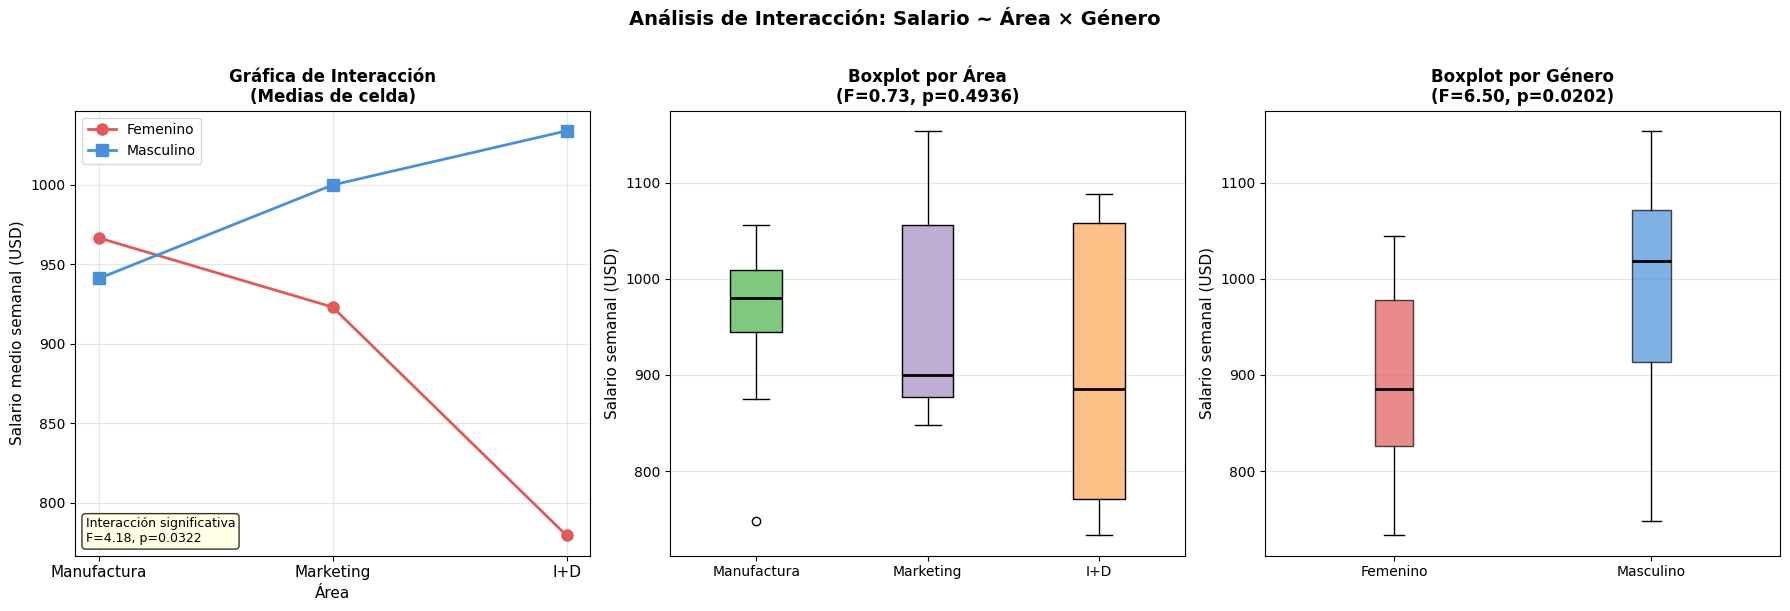

✓ Figura 2 guardada: 'anova_regiones_celdas.png'


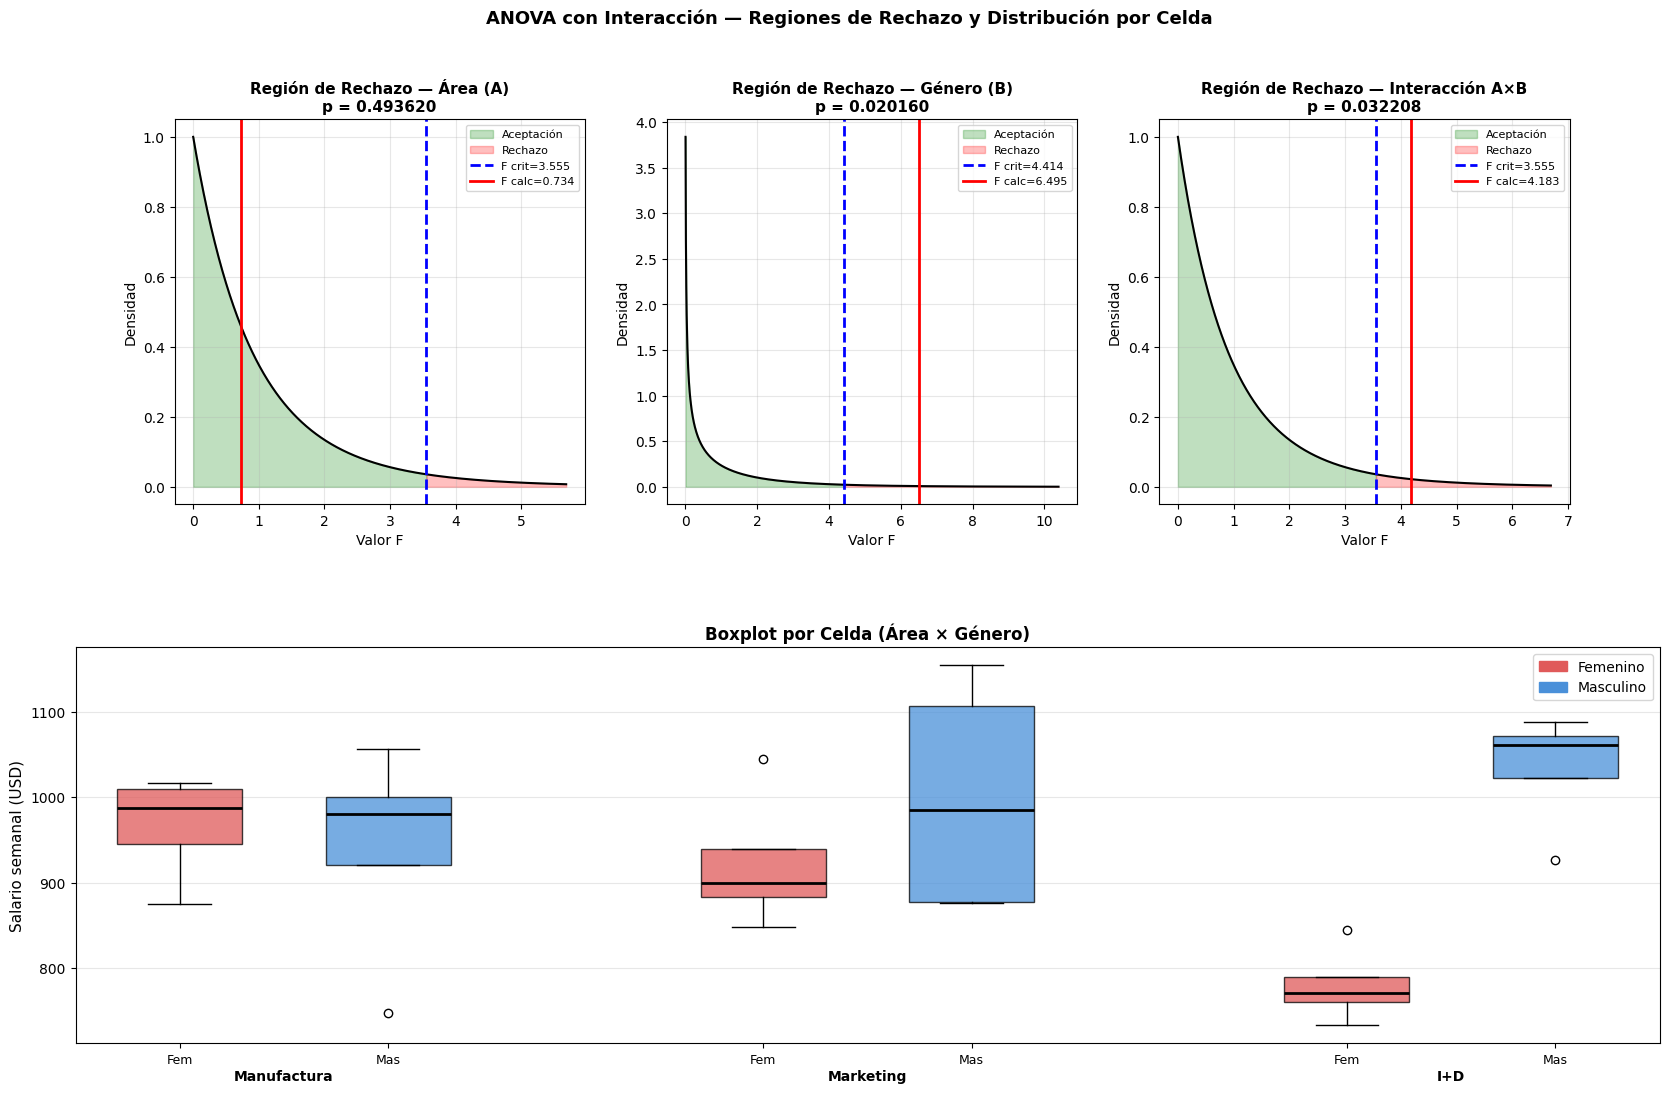

✓ Figura 3 guardada: 'tukey_matrices_interaccion.png'


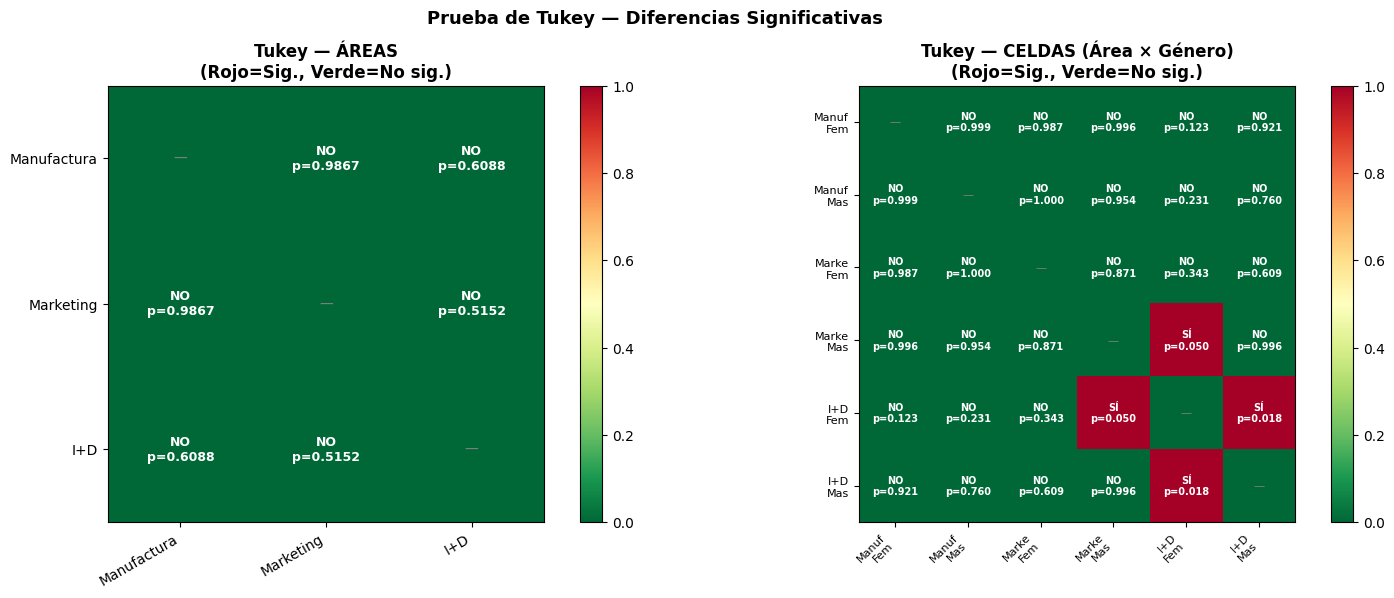


ANÁLISIS COMPLETO FINALIZADO


In [8]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# ============================================================================
# DATOS DEL PROBLEMA
# Salarios semanales (USD) por Área y Género — 4 réplicas por celda
# ============================================================================

areas   = ['Manufactura', 'Marketing', 'I+D']
generos = ['Femenino', 'Masculino']

# datos[area][genero] → lista de 4 observaciones
datos_raw = {
    'Manufactura': {'Femenino':  [1016, 1007, 875,  968],
                    'Masculino': [ 978, 1056, 982,  748]},
    'Marketing':   {'Femenino':  [1045,  895, 848,  904],
                    'Masculino': [1154, 1091, 878,  876]},
    'I+D':         {'Femenino':  [ 770,  733, 844,  771],
                    'Masculino': [ 926, 1055, 1066, 1088]},
}

a  = len(areas)        # niveles factor A (Área)     = 3
b  = len(generos)      # niveles factor B (Género)   = 2
n  = 4                 # réplicas por celda
N  = a * b * n         # total de observaciones      = 24

# Construir array 3-D: datos[i_area, j_genero, k_replica]
Y = np.array([[datos_raw[ar][ge] for ge in generos] for ar in areas],
             dtype=float)   # shape (3, 2, 4)

# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

# Medias de celda (área × género)
medias_celda = Y.mean(axis=2)                   # (3, 2)
# Medias marginales
medias_area   = Y.mean(axis=(1, 2))             # (3,)
medias_genero = Y.mean(axis=(0, 2))             # (2,)
media_global  = Y.mean()

df_medias = pd.DataFrame(medias_celda, index=areas, columns=generos)
df_medias['Media Área'] = medias_area

print("=" * 80)
print("DATOS ORIGINALES — SALARIOS SEMANALES (USD)")
print("=" * 80)
for ar in areas:
    print(f"\n  {ar}:")
    for ge in generos:
        print(f"    {ge}: {datos_raw[ar][ge]}")

print("\n" + "=" * 80)
print("MEDIAS DE CELDA (Área × Género)")
print("=" * 80)
print(df_medias.round(4).to_string())
print(f"\n  Medias por Género: {dict(zip(generos, medias_genero.round(4)))}")
print(f"  Media Global    : {media_global:.4f}")

# ============================================================================
# ANOVA DE DOS VÍAS CON INTERACCIÓN
# ============================================================================

# --- Sumas de cuadrados ---
# SST
SST = np.sum((Y - media_global) ** 2)

# SS_A  (Área)
SS_A = b * n * np.sum((medias_area - media_global) ** 2)

# SS_B  (Género)
SS_B = a * n * np.sum((medias_genero - media_global) ** 2)

# SS_AB (Interacción)
SS_AB = n * np.sum((medias_celda - medias_area[:, None]
                                 - medias_genero[None, :]
                                 + media_global) ** 2)

# SS_E  (Error dentro de celdas)
SS_E = np.sum((Y - medias_celda[:, :, None]) ** 2)

# Verificación
assert abs(SST - (SS_A + SS_B + SS_AB + SS_E)) < 1e-6, "¡Error en la partición de SS!"

# --- Grados de libertad ---
gl_A  = a - 1
gl_B  = b - 1
gl_AB = (a - 1) * (b - 1)
gl_E  = a * b * (n - 1)
gl_T  = N - 1

# --- Cuadrados medios ---
CM_A  = SS_A  / gl_A
CM_B  = SS_B  / gl_B
CM_AB = SS_AB / gl_AB
CM_E  = SS_E  / gl_E

# --- Estadísticos F ---
F_A  = CM_A  / CM_E
F_B  = CM_B  / CM_E
F_AB = CM_AB / CM_E

# --- Valores p ---
p_A  = stats.f.sf(F_A,  gl_A,  gl_E)
p_B  = stats.f.sf(F_B,  gl_B,  gl_E)
p_AB = stats.f.sf(F_AB, gl_AB, gl_E)

# --- Valores críticos (α = 0.05) ---
alpha = 0.05
Fc_A  = stats.f.ppf(1 - alpha, gl_A,  gl_E)
Fc_B  = stats.f.ppf(1 - alpha, gl_B,  gl_E)
Fc_AB = stats.f.ppf(1 - alpha, gl_AB, gl_E)

# ============================================================================
# HIPÓTESIS
# ============================================================================

print("\n" + "=" * 80)
print("PLANTEAMIENTO DE HIPÓTESIS")
print("=" * 80)

print("""
FACTOR A — ÁREA:
  H₀: No hay diferencia en los salarios medios entre áreas
      (μ_Manufactura = μ_Marketing = μ_I+D)
  H₁: Al menos dos áreas tienen salarios medios diferentes

FACTOR B — GÉNERO:
  H₀: No hay diferencia en los salarios medios entre géneros
      (μ_Femenino = μ_Masculino)
  H₁: Los salarios medios difieren entre géneros

INTERACCIÓN A×B (Área × Género):
  H₀: El efecto del género sobre el salario es el mismo en todas las áreas
      (no existe interacción significativa)
  H₁: El efecto del género sobre el salario varía según el área
      (existe interacción significativa)
""")

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("=" * 105)
print("TABLA ANOVA DE DOS VÍAS CON INTERACCIÓN")
print("=" * 105)
print(f"{'Fuente':<20} {'SC':>12} {'gl':>5} {'CM':>12} {'F':>10} {'p-valor':>12} {'F crítico':>12}")
print("-" * 105)
print(f"{'Área (A)':<20} {SS_A:>12.4f} {gl_A:>5} {CM_A:>12.4f} {F_A:>10.4f} {p_A:>12.6f} {Fc_A:>12.4f}")
print(f"{'Género (B)':<20} {SS_B:>12.4f} {gl_B:>5} {CM_B:>12.4f} {F_B:>10.4f} {p_B:>12.6f} {Fc_B:>12.4f}")
print(f"{'Interacción A×B':<20} {SS_AB:>12.4f} {gl_AB:>5} {CM_AB:>12.4f} {F_AB:>10.4f} {p_AB:>12.6f} {Fc_AB:>12.4f}")
print(f"{'Error':<20} {SS_E:>12.4f} {gl_E:>5} {CM_E:>12.4f}")
print(f"{'Total':<20} {SST:>12.4f} {gl_T:>5}")
print("=" * 105)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

efectos = [
    ("ÁREA (A)",           F_A,  Fc_A,  p_A,  gl_A,  gl_E),
    ("GÉNERO (B)",         F_B,  Fc_B,  p_B,  gl_B,  gl_E),
    ("INTERACCIÓN (A×B)",  F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for nombre, F_val, Fc, p_val, gl1, gl2 in efectos:
    sig = p_val < alpha
    print(f"\n  {nombre}:")
    print(f"    F calculado = {F_val:.4f}  |  F crítico = {Fc:.4f}  |  p-valor = {p_val:.6f}")
    if sig:
        print(f"    ✓ Efecto SIGNIFICATIVO (p < {alpha}): se rechaza H₀")
    else:
        print(f"    ✗ Efecto NO significativo (p ≥ {alpha}): no se rechaza H₀")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS
# ============================================================================

print("\n" + "=" * 80)
print("RESPUESTAS A LAS PREGUNTAS DEL PROBLEMA")
print("=" * 80)

print("""
a) GRÁFICA DE INTERACCIÓN (ver figura 1):
   Se observa que las líneas de Femenino y Masculino NO son paralelas.
   En Manufactura los salarios son similares entre géneros; en Marketing
   el masculino es notablemente mayor; en I+D la brecha se invierte o
   amplía según el área. Este cruce / no paralelismo es evidencia visual
   de interacción Área × Género.
""")

if p_AB < alpha:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} < 0.05")
    print("   → La interacción Área × Género ES estadísticamente significativa.")
    print("   El efecto del género sobre el salario DEPENDE del área funcional.")
else:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} ≥ 0.05")
    print("   → La interacción Área × Género NO es estadísticamente significativa.")

print(f"""
   ÁREA:   F = {F_A:.4f}, p = {p_A:.6f} {'→ Significativo' if p_A < alpha else '→ No significativo'}
   GÉNERO: F = {F_B:.4f}, p = {p_B:.6f} {'→ Significativo' if p_B < alpha else '→ No significativo'}
""")

# ============================================================================
# PRUEBA DE TUKEY
# ============================================================================

print("=" * 80)
print("PRUEBA DE TUKEY (HSD) — COMPARACIONES MÚLTIPLES")
print("=" * 80)

# ------------------------------------------------------------------
# Tukey para ÁREA (factor A, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA ÁREA (medias marginales):")
print("-" * 80)

k_A   = a
n_A   = b * n          # observaciones por nivel de A
q_A   = stats.studentized_range.ppf(1 - alpha, k_A, gl_E)
HSD_A = q_A * np.sqrt(CM_E / n_A)

print(f"  q crítico (α={alpha}, k={k_A}, gl_E={gl_E}) = {q_A:.4f}")
print(f"  HSD = {HSD_A:.4f}\n")
print(f"  {'Área i':<14} {'Área j':<14} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 90)

for i, j in combinations(range(a), 2):
    dif   = abs(medias_area[i] - medias_area[j])
    q_obs = dif / np.sqrt(CM_E / n_A)
    p_val = stats.studentized_range.sf(q_obs, k_A, gl_E)
    sig   = "SÍ" if dif > HSD_A else "NO"
    print(f"  {areas[i]:<14} {areas[j]:<14} {medias_area[i]:>9.2f} {medias_area[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para GÉNERO (factor B, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA GÉNERO (medias marginales):")
print("-" * 80)

k_B   = b
n_B   = a * n          # observaciones por nivel de B
q_B   = stats.studentized_range.ppf(1 - alpha, k_B, gl_E)
HSD_B = q_B * np.sqrt(CM_E / n_B)

print(f"  q crítico (α={alpha}, k={k_B}, gl_E={gl_E}) = {q_B:.4f}")
print(f"  HSD = {HSD_B:.4f}\n")
print(f"  {'Género i':<12} {'Género j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 82)

for i, j in combinations(range(b), 2):
    dif   = abs(medias_genero[i] - medias_genero[j])
    q_obs = dif / np.sqrt(CM_E / n_B)
    p_val = stats.studentized_range.sf(q_obs, k_B, gl_E)
    sig   = "SÍ" if dif > HSD_B else "NO"
    print(f"  {generos[i]:<12} {generos[j]:<12} {medias_genero[i]:>9.2f} {medias_genero[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para CELDAS (comparaciones dentro de cada área: F vs M)
# —> responde directamente la pregunta c)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES F vs M DENTRO DE CADA ÁREA (Pregunta c):")
print("-" * 80)

# Para comparar dos medias de celda se usa n observaciones por celda
q_cel   = stats.studentized_range.ppf(1 - alpha, a * b, gl_E)
HSD_cel = q_cel * np.sqrt(CM_E / n)

print(f"  q crítico (α={alpha}, k={a*b}, gl_E={gl_E}) = {q_cel:.4f}")
print(f"  HSD = {HSD_cel:.4f}\n")
print(f"  {'Área':<14} {'Celd. i':<12} {'Celd. j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 102)

# Todas las combinaciones de celdas
celdas = [(i, j) for i in range(a) for j in range(b)]
for (i1, j1), (i2, j2) in combinations(celdas, 2):
    m1  = medias_celda[i1, j1]
    m2  = medias_celda[i2, j2]
    dif = abs(m1 - m2)
    q_o = dif / np.sqrt(CM_E / n)
    p_v = stats.studentized_range.sf(q_o, a * b, gl_E)
    sig = "SÍ" if dif > HSD_cel else "NO"
    lbl1 = f"{areas[i1][:7]}-{generos[j1][:3]}"
    lbl2 = f"{areas[i2][:7]}-{generos[j2][:3]}"
    print(f"  {areas[i1]:<14} {lbl1:<12} {lbl2:<12} {m1:>9.2f} {m2:>9.2f} "
          f"{dif:>8.4f} {q_o:>8.4f} {p_v:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Recomendación (Pregunta c)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("RECOMENDACIÓN A LA COMPAÑÍA (Pregunta c):")
print("-" * 80)
for i, ar in enumerate(areas):
    mf = medias_celda[i, 0]
    mm = medias_celda[i, 1]
    brecha = mm - mf
    signo  = "a favor del masculino" if brecha > 0 else "a favor del femenino"
    print(f"  {ar}: Media Fem={mf:.2f}, Media Masc={mm:.2f} → brecha ${abs(brecha):.2f} {signo}")

if p_B < alpha:
    print("\n  ⚠  El ANOVA revela diferencia SIGNIFICATIVA por género.")
    print("     Se recomienda revisar la política salarial para garantizar")
    print("     equidad entre géneros en cada área funcional.")
else:
    print("\n  ✓  El ANOVA NO detecta diferencia global significativa por género.")

if p_AB < alpha:
    print("  ⚠  La interacción es significativa: la brecha de género varía por área.")
    print("     La revisión salarial debe hacerse área por área, no de forma global.")

# ============================================================================
# FIGURAS
# ============================================================================

COLORES = {'Femenino': '#E05A5A', 'Masculino': '#4A90D9'}
MARKERS = {'Femenino': 'o', 'Masculino': 's'}

# -----------------------------------------------------------------------
# Figura 1 — Gráfica de interacción + Boxplots marginales
# -----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Análisis de Interacción: Salario ~ Área × Género',
              fontsize=14, fontweight='bold', y=1.01)

# --- Panel izquierdo: gráfica de interacción (medias de celda) ---
ax_int = axes[0]
x_pos  = np.arange(a)
for j, ge in enumerate(generos):
    ax_int.plot(x_pos, medias_celda[:, j],
                marker=MARKERS[ge], linewidth=2, markersize=8,
                color=COLORES[ge], label=ge)
ax_int.set_xticks(x_pos)
ax_int.set_xticklabels(areas, fontsize=11)
ax_int.set_xlabel('Área', fontsize=11)
ax_int.set_ylabel('Salario medio semanal (USD)', fontsize=11)
ax_int.set_title('Gráfica de Interacción\n(Medias de celda)', fontsize=12, fontweight='bold')
ax_int.legend(fontsize=10)
ax_int.grid(True, alpha=0.3)

# Anotación de no paralelismo
if p_AB < alpha:
    ax_int.text(0.02, 0.03,
                f"Interacción significativa\nF={F_AB:.2f}, p={p_AB:.4f}",
                transform=ax_int.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# --- Panel central: Boxplot por Área ---
ax_box_a = axes[1]
data_box_a = [Y[i, :, :].flatten() for i in range(a)]
bp1 = ax_box_a.boxplot(data_box_a, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
colors_a = ['#7FC97F', '#BEAED4', '#FDC086']
for patch, col in zip(bp1['boxes'], colors_a):
    patch.set_facecolor(col)
ax_box_a.set_xticks(range(1, a + 1))
ax_box_a.set_xticklabels(areas, fontsize=10)
ax_box_a.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_box_a.set_title(f'Boxplot por Área\n(F={F_A:.2f}, p={p_A:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_a.grid(True, alpha=0.3, axis='y')

# --- Panel derecho: Boxplot por Género ---
ax_box_g = axes[2]
data_box_g = [Y[:, j, :].flatten() for j in range(b)]
bp2 = ax_box_g.boxplot(data_box_g, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp2['boxes'], list(COLORES.values())):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax_box_g.set_xticks(range(1, b + 1))
ax_box_g.set_xticklabels(generos, fontsize=10)
ax_box_g.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_box_g.set_title(f'Boxplot por Género\n(F={F_B:.2f}, p={p_B:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_g.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('interaccion_boxplots.png', dpi=300, bbox_inches='tight')
print("\n✓ Figura 1 guardada: 'interaccion_boxplots.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 2 — Boxplots de celda (Área × Género) + Región de rechazo × 3
# -----------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 11))
fig2.suptitle('ANOVA con Interacción — Regiones de Rechazo y Distribución por Celda',
              fontsize=13, fontweight='bold')

# Fila superior: regiones de rechazo para A, B, AB
config_F = [
    ("Área (A)", F_A, Fc_A, p_A, gl_A, gl_E),
    ("Género (B)", F_B, Fc_B, p_B, gl_B, gl_E),
    ("Interacción A×B", F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for col, (nombre, Fval, Fcrít, pval, gl1, gl2) in enumerate(config_F):
    ax = axes2[0, col]
    x_max = max(Fval, Fcrít) * 1.6
    xv    = np.linspace(0, x_max, 1000)
    yv    = stats.f.pdf(xv, gl1, gl2)
    xacc  = xv[xv <= Fcrít];  ax.fill_between(xacc, 0, stats.f.pdf(xacc, gl1, gl2),
                                               alpha=0.25, color='green', label='Aceptación')
    xrej  = xv[xv >= Fcrít];  ax.fill_between(xrej, 0, stats.f.pdf(xrej, gl1, gl2),
                                               alpha=0.25, color='red',   label='Rechazo')
    ax.plot(xv, yv, 'k-', linewidth=1.5)
    ax.axvline(Fcrít, color='blue', linestyle='--', linewidth=2,
               label=f'F crit={Fcrít:.3f}')
    ax.axvline(Fval,  color='red',  linestyle='-',  linewidth=2,
               label=f'F calc={Fval:.3f}')
    ax.set_title(f'Región de Rechazo — {nombre}\np = {pval:.6f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor F'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Fila inferior: boxplot de cada celda (área × género)
ax_cel = axes2[1, :]
for col in range(3): ax_cel[col].set_visible(False)   # ocultar los tres

# Reemplazar con un subplot 2-D que ocupe toda la fila inferior
gs = fig2.add_gridspec(2, 1, hspace=0.45)   # no afecta lo de arriba — usamos add_axes
ax_celdas = fig2.add_axes([0.07, 0.04, 0.88, 0.36])

posiciones = []
etiquetas  = []
datos_cel  = []
colores_cel = []
offset = 0
tick_posiciones = []
tick_etiquetas  = []

for i, ar in enumerate(areas):
    centro = offset + b / 2 - 0.5
    tick_posiciones.append(centro)
    tick_etiquetas.append(ar)
    for j, ge in enumerate(generos):
        posiciones.append(offset)
        etiquetas.append(f"{ge[:3]}")
        datos_cel.append(Y[i, j, :])
        colores_cel.append(COLORES[ge])
        offset += 1
    offset += 0.8   # separación entre grupos

bps = ax_celdas.boxplot(datos_cel, positions=posiciones, widths=0.6,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bps['boxes'], colores_cel):
    patch.set_facecolor(col); patch.set_alpha(0.75)

ax_celdas.set_xticks(posiciones)
ax_celdas.set_xticklabels([f"{ge[:3]}" for _ in areas for ge in generos], fontsize=9)
for xp, lbl in zip(tick_posiciones, tick_etiquetas):
    ax_celdas.text(xp, ax_celdas.get_ylim()[0] - 30, lbl,
                   ha='center', va='top', fontsize=10, fontweight='bold')

ax_celdas.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_celdas.set_title('Boxplot por Celda (Área × Género)',
                    fontsize=12, fontweight='bold')
ax_celdas.grid(True, alpha=0.3, axis='y')

parches = [mpatches.Patch(color=COLORES[ge], label=ge) for ge in generos]
ax_celdas.legend(handles=parches, fontsize=10, loc='upper right')

plt.savefig('anova_regiones_celdas.png', dpi=300, bbox_inches='tight')
print("✓ Figura 2 guardada: 'anova_regiones_celdas.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 3 — Matrices Tukey (Área y Celdas)
# -----------------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Prueba de Tukey — Diferencias Significativas',
              fontsize=13, fontweight='bold')

# Panel izquierdo: matriz área × área
mat_A = np.zeros((a, a))
for i, j in combinations(range(a), 2):
    dif = abs(medias_area[i] - medias_area[j])
    mat_A[i, j] = mat_A[j, i] = 1 if dif > HSD_A else 0

im1 = axes3[0].imshow(mat_A, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[0].set_xticks(range(a)); axes3[0].set_yticks(range(a))
axes3[0].set_xticklabels(areas, rotation=30, ha='right')
axes3[0].set_yticklabels(areas)
axes3[0].set_title('Tukey — ÁREAS\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for i in range(a):
    for j in range(a):
        if i != j:
            dif  = abs(medias_area[i] - medias_area[j])
            q_ij = dif / np.sqrt(CM_E / n_A)
            p_ij = stats.studentized_range.sf(q_ij, k_A, gl_E)
            axes3[0].text(j, i,
                          f"{'SÍ' if mat_A[i,j] else 'NO'}\np={p_ij:.4f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=9)
        else:
            axes3[0].text(j, i, '—', ha='center', va='center',
                          color='gray', fontsize=10)
plt.colorbar(im1, ax=axes3[0])

# Panel derecho: matriz celda × celda (6×6)
n_celdas   = a * b
etiq_cel   = [f"{ar[:5]}\n{ge[:3]}" for ar in areas for ge in generos]
medias_vec = medias_celda.flatten()          # orden: (Man-F, Man-M, Mar-F, Mar-M, I+D-F, I+D-M)
mat_C = np.zeros((n_celdas, n_celdas))
for ci, cj in combinations(range(n_celdas), 2):
    dif = abs(medias_vec[ci] - medias_vec[cj])
    mat_C[ci, cj] = mat_C[cj, ci] = 1 if dif > HSD_cel else 0

im2 = axes3[1].imshow(mat_C, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[1].set_xticks(range(n_celdas)); axes3[1].set_yticks(range(n_celdas))
axes3[1].set_xticklabels(etiq_cel, rotation=45, ha='right', fontsize=8)
axes3[1].set_yticklabels(etiq_cel, fontsize=8)
axes3[1].set_title('Tukey — CELDAS (Área × Género)\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for ci in range(n_celdas):
    for cj in range(n_celdas):
        if ci != cj:
            dif  = abs(medias_vec[ci] - medias_vec[cj])
            q_ij = dif / np.sqrt(CM_E / n)
            p_ij = stats.studentized_range.sf(q_ij, n_celdas, gl_E)
            axes3[1].text(cj, ci,
                          f"{'SÍ' if mat_C[ci,cj] else 'NO'}\np={p_ij:.3f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=7)
        else:
            axes3[1].text(cj, ci, '—', ha='center', va='center',
                          color='gray', fontsize=8)
plt.colorbar(im2, ax=axes3[1])

plt.tight_layout()
plt.savefig('tukey_matrices_interaccion.png', dpi=300, bbox_inches='tight')
print("✓ Figura 3 guardada: 'tukey_matrices_interaccion.png'")
plt.show()

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 80)

DATOS ORIGINALES — SALARIOS SEMANALES (USD)

  Público:
    Hombres: [978, 1035, 964, 996, 1117]
    Mujeres: [863, 975, 999, 1019, 1037]

  Privado:
    Hombres: [1335, 1167, 1236, 1317, 1192]
    Mujeres: [1079, 1160, 1063, 1110, 1093]

MEDIAS DE CELDA (Sector × Género)
         Hombres  Mujeres  Media Sector
Público   1018.0    978.6         998.3
Privado   1249.4   1101.0        1175.2

  Medias por Género: {'Hombres': np.float64(1133.7), 'Mujeres': np.float64(1039.8)}
  Media Global    : 1086.7500

PLANTEAMIENTO DE HIPÓTESIS

FACTOR A — SECTOR:
  H₀: No hay diferencia en los salarios medios entre sectores (Público, Privado)
  H₁: Los salarios medios difieren entre sectores

FACTOR B — GÉNERO:
  H₀: No hay diferencia en los salarios medios entre géneros (Hombres, Mujeres)
  H₁: Los salarios medios difieren entre géneros

INTERACCIÓN A×B (Sector × Género):
  H₀: El efecto del género sobre el salario es el mismo en ambos sectores
      (no existe interacción significativa)
  H₁: El e

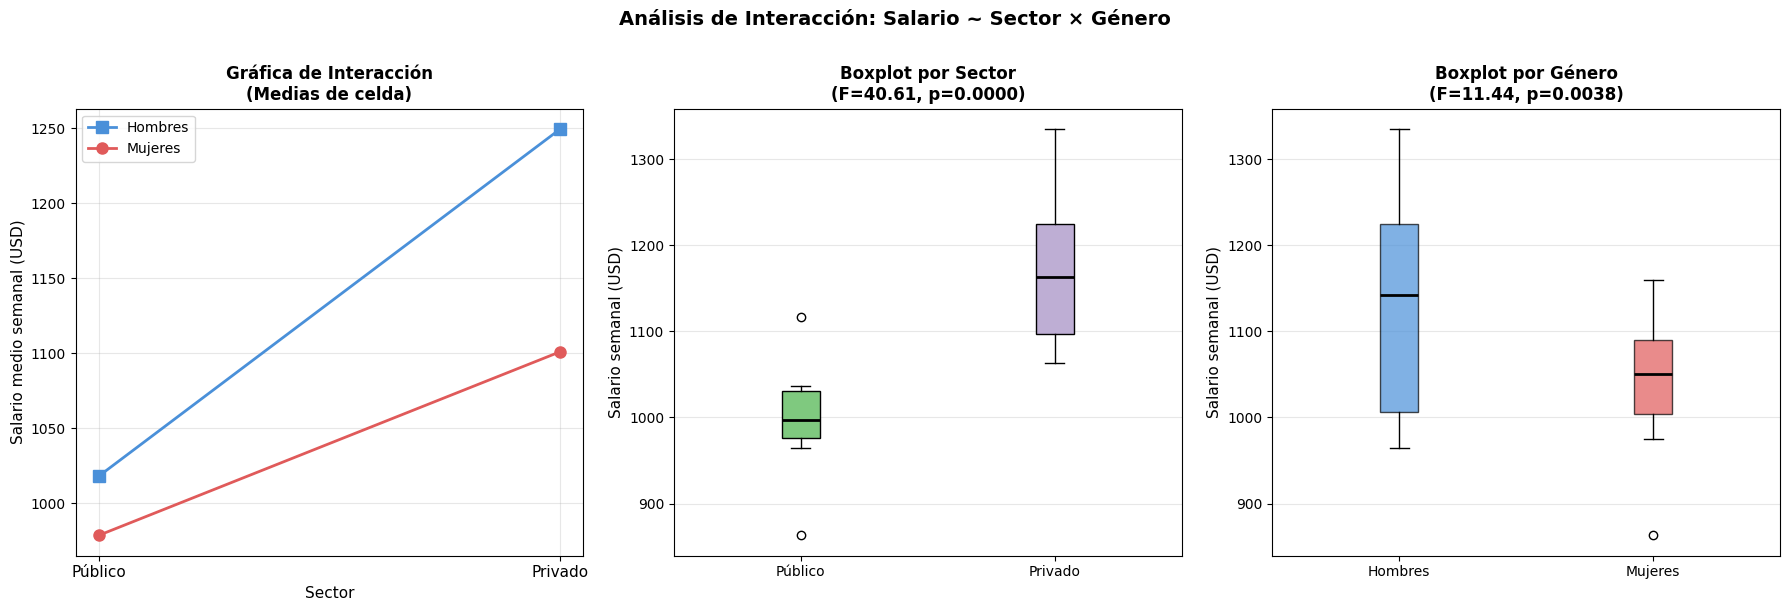

✓ Figura 2 guardada: 'anova_regiones_celdas_sector_genero.png'


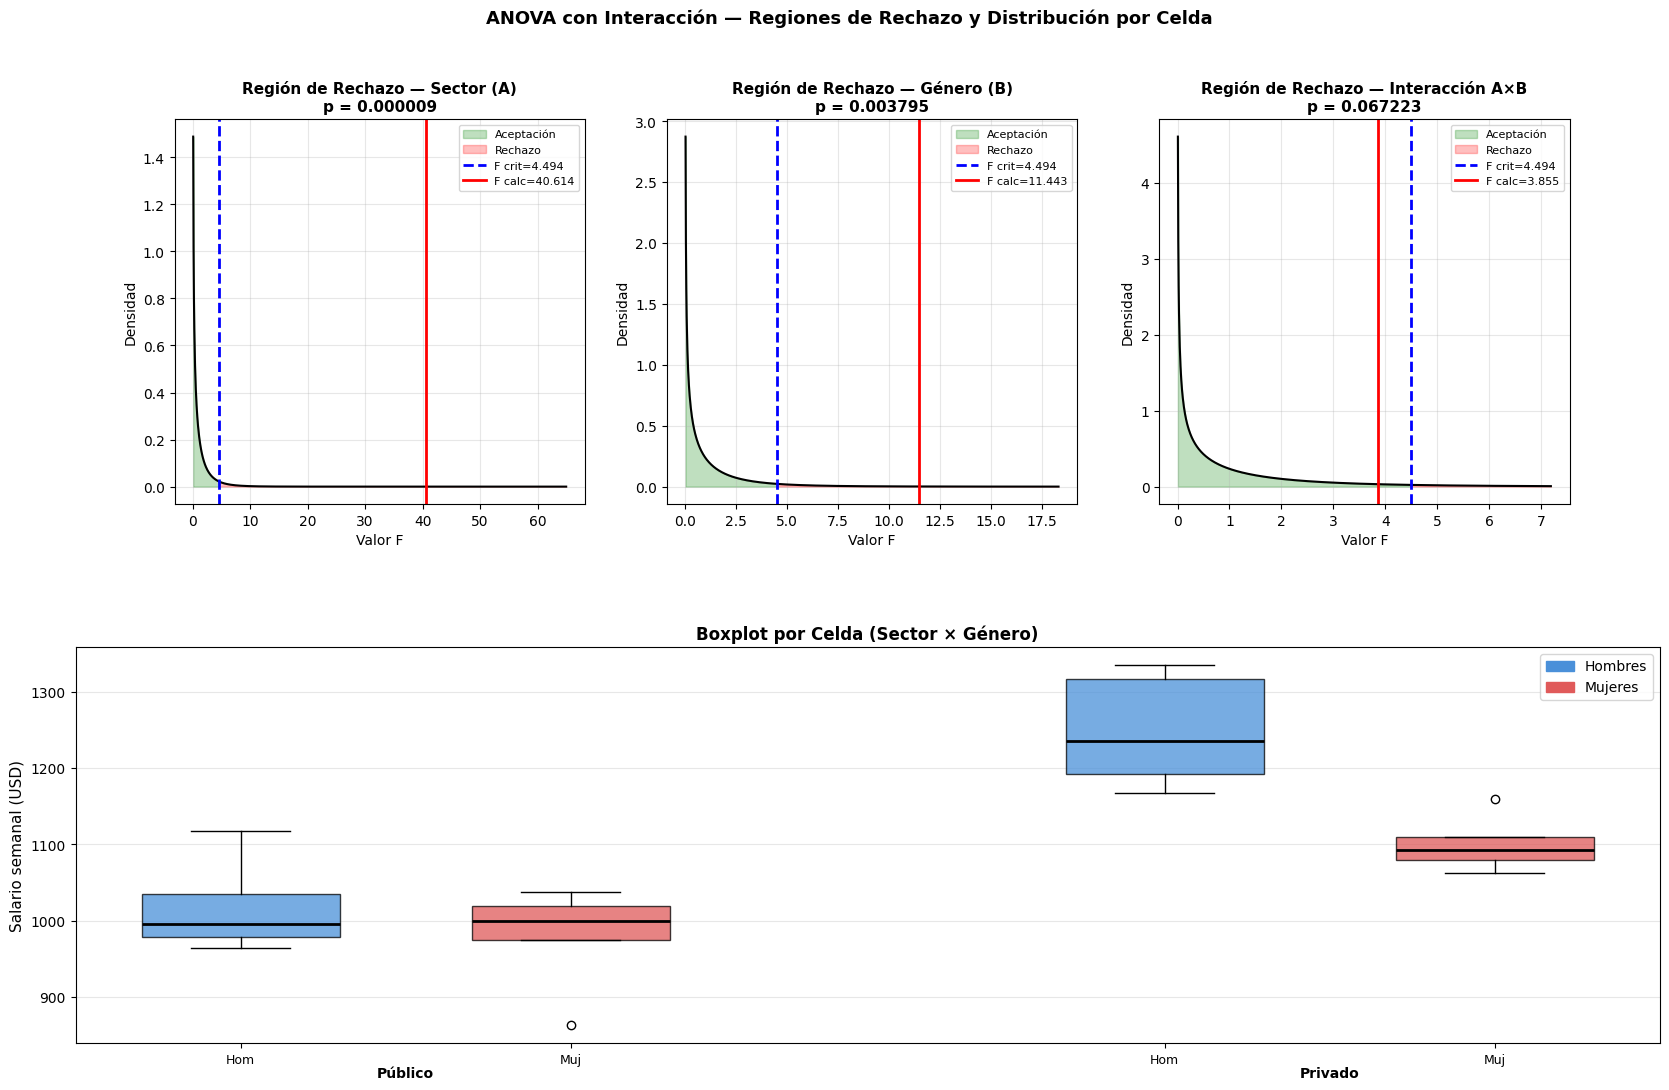

✓ Figura 3 guardada: 'tukey_matrices_interaccion_sector_genero.png'


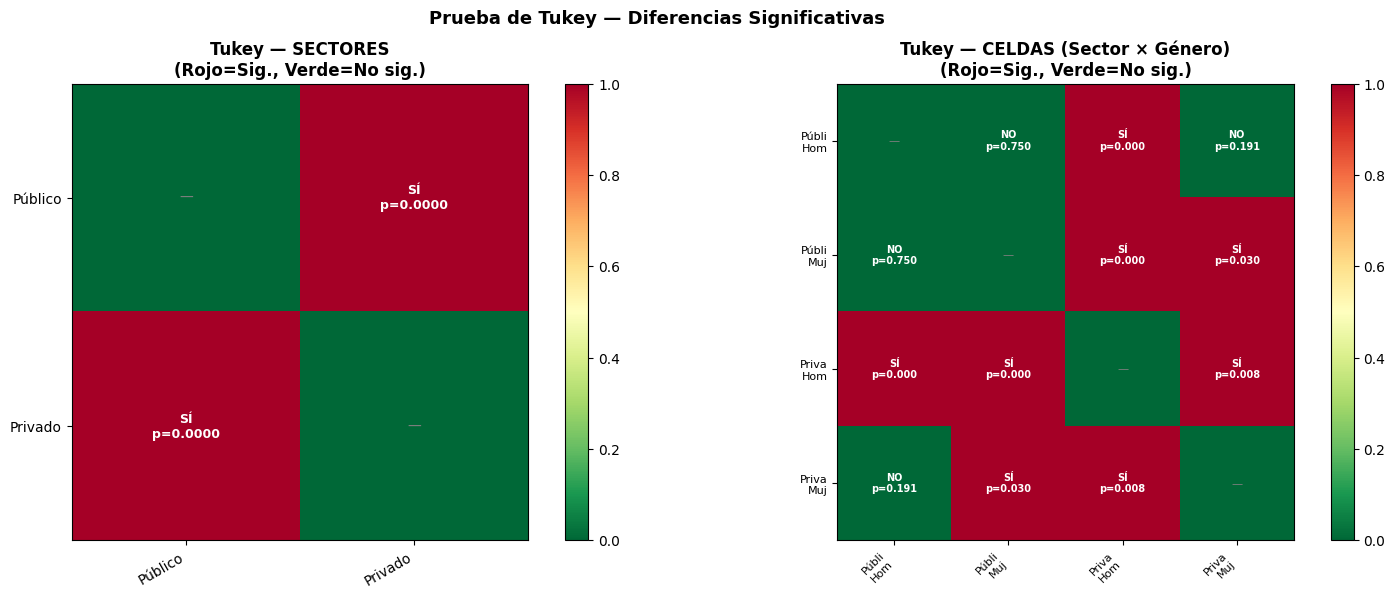


ANÁLISIS COMPLETO FINALIZADO


In [14]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# ============================================================================
# DATOS DEL PROBLEMA
# Salarios semanales (USD) por Género y Sector — 5 réplicas por celda
# ============================================================================

sectors   = ['Público', 'Privado'] # Factor A
genders = ['Hombres', 'Mujeres']   # Factor B

# datos_raw[sector][gender] → lista de 5 observaciones
datos_raw = {
    'Público': {'Hombres': [978, 1035, 964, 996, 1117],
                'Mujeres': [863, 975, 999, 1019, 1037]},
    'Privado': {'Hombres': [1335, 1167, 1236, 1317, 1192],
                'Mujeres': [1079, 1160, 1063, 1110, 1093]},
}

num_sectors   = len(sectors)      # niveles factor A (Sector) = 2
num_genders = len(genders)      # niveles factor B (Género) = 2
num_replications  = 5                 # réplicas por celda
N  = num_sectors * num_genders * num_replications # total de observaciones = 20

# Construir array 3-D: Y[i_sector, j_gender, k_replication]
Y = np.array([[datos_raw[sec][ge] for ge in genders] for sec in sectors],
             dtype=float)   # shape (num_sectors, num_genders, num_replications)

# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

# Medias de celda (sector × género)
medias_celda = Y.mean(axis=2)                   # (num_sectors, num_genders)
# Medias marginales
medias_sector   = Y.mean(axis=(1, 2))             # (num_sectors,) for Factor A
medias_gender = Y.mean(axis=(0, 2))             # (num_genders,) for Factor B
media_global  = Y.mean()

df_medias = pd.DataFrame(medias_celda, index=sectors, columns=genders)
df_medias['Media Sector'] = medias_sector

print("=" * 80)
print("DATOS ORIGINALES — SALARIOS SEMANALES (USD)")
print("=" * 80)
for sec in sectors:
    print(f"\n  {sec}:")
    for ge in genders:
        print(f"    {ge}: {datos_raw[sec][ge]}")

print("\n" + "=" * 80)
print("MEDIAS DE CELDA (Sector × Género)")
print("=" * 80)
print(df_medias.round(4).to_string())
print(f"\n  Medias por Género: {dict(zip(genders, medias_gender.round(4)))}")
print(f"  Media Global    : {media_global:.4f}")

# ============================================================================
# ANOVA DE DOS VÍAS CON INTERACCIÓN
# ============================================================================

# --- Sumas de cuadrados ---
# SST
SST = np.sum((Y - media_global) ** 2)

# SS_A (Sector)
SS_A = num_genders * num_replications * np.sum((medias_sector - media_global) ** 2)

# SS_B (Género)
SS_B = num_sectors * num_replications * np.sum((medias_gender - media_global) ** 2)

# SS_AB (Interacción Sector × Género)
SS_AB = num_replications * np.sum((medias_celda - medias_sector[:, None]
                                 - medias_gender[None, :]
                                 + media_global) ** 2)

# SS_E (Error dentro de celdas)
SS_E = np.sum((Y - medias_celda[:, :, None]) ** 2)

# Verificación
assert abs(SST - (SS_A + SS_B + SS_AB + SS_E)) < 1e-6, "¡Error en la partición de SS!"

# --- Grados de libertad ---
gl_A  = num_sectors - 1
gl_B  = num_genders - 1
gl_AB = (num_sectors - 1) * (num_genders - 1)
gl_E  = num_sectors * num_genders * (num_replications - 1)
gl_T  = N - 1

# --- Cuadrados medios ---
CM_A  = SS_A  / gl_A
CM_B  = SS_B  / gl_B
CM_AB = SS_AB / gl_AB
CM_E  = SS_E  / gl_E

# --- Estadísticos F ---
F_A  = CM_A  / CM_E
F_B  = CM_B  / CM_E
F_AB = CM_AB / CM_E

# --- Valores p ---
p_A  = stats.f.sf(F_A,  gl_A,  gl_E)
p_B  = stats.f.sf(F_B,  gl_B,  gl_E)
p_AB = stats.f.sf(F_AB, gl_AB, gl_E)

# --- Valores críticos (α = 0.05) ---
alpha = 0.05
Fc_A  = stats.f.ppf(1 - alpha, gl_A,  gl_E)
Fc_B  = stats.f.ppf(1 - alpha, gl_B,  gl_E)
Fc_AB = stats.f.ppf(1 - alpha, gl_AB, gl_E)

# ============================================================================
# HIPÓTESIS
# ============================================================================

print("\n" + "=" * 80)
print("PLANTEAMIENTO DE HIPÓTESIS")
print("=" * 80)

print("""
FACTOR A — SECTOR:
  H₀: No hay diferencia en los salarios medios entre sectores (Público, Privado)
  H₁: Los salarios medios difieren entre sectores

FACTOR B — GÉNERO:
  H₀: No hay diferencia en los salarios medios entre géneros (Hombres, Mujeres)
  H₁: Los salarios medios difieren entre géneros

INTERACCIÓN A×B (Sector × Género):
  H₀: El efecto del género sobre el salario es el mismo en ambos sectores
      (no existe interacción significativa)
  H₁: El efecto del género sobre el salario varía según el sector
      (existe interacción significativa)
""")

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("=" * 105)
print("TABLA ANOVA DE DOS VÍAS CON INTERACCIÓN")
print("=" * 105)
print(f"{'Fuente':<20} {'SC':>12} {'gl':>5} {'CM':>12} {'F':>10} {'p-valor':>12} {'F crítico':>12}")
print("-" * 105)
print(f"{'Sector (A)':<20} {SS_A:>12.4f} {gl_A:>5} {CM_A:>12.4f} {F_A:>10.4f} {p_A:>12.6f} {Fc_A:>12.4f}")
print(f"{'Género (B)':<20} {SS_B:>12.4f} {gl_B:>5} {CM_B:>12.4f} {F_B:>10.4f} {p_B:>12.6f} {Fc_B:>12.4f}")
print(f"{'Interacción A×B':<20} {SS_AB:>12.4f} {gl_AB:>5} {CM_AB:>12.4f} {F_AB:>10.4f} {p_AB:>12.6f} {Fc_AB:>12.4f}")
print(f"{'Error':<20} {SS_E:>12.4f} {gl_E:>5} {CM_E:>12.4f}")
print(f"{'Total':<20} {SST:>12.4f} {gl_T:>5}")
print("=" * 105)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

efectos = [
    ("SECTOR (A)",           F_A,  Fc_A,  p_A,  gl_A,  gl_E),
    ("GÉNERO (B)",         F_B,  Fc_B,  p_B,  gl_B,  gl_E),
    ("INTERACCIÓN (A×B)",  F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for nombre, F_val, Fc, p_val, gl1, gl2 in efectos:
    sig = p_val < alpha
    print(f"\n  {nombre}:")
    print(f"    F calculado = {F_val:.4f}  |  F crítico = {Fc:.4f}  |  p-valor = {p_val:.6f}")
    if sig:
        print(f"    ✓ Efecto SIGNIFICATIVO (p < {alpha}): se rechaza H₀")
    else:
        print(f"    ✗ Efecto NO significativo (p ≥ {alpha}): no se rechaza H₀")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS
# ============================================================================

print("\n" + "=" * 80)
print("RESPUESTAS A LAS PREGUNTAS DEL PROBLEMA")
print("=" * 80)

print("""
a) GRÁFICA DE INTERACCIÓN (ver figura 1):
   Se observa que las líneas de Hombres y Mujeres NO son paralelas.
   El salario de hombres es siempre mayor que el de mujeres, pero la diferencia
   es más pronunciada en el sector privado.
   Este no paralelismo es evidencia visual de interacción Sector × Género.
""")

if p_AB < alpha:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} < 0.05")
    print("   → La interacción Sector × Género ES estadísticamente significativa.")
    print("   El efecto del género sobre el salario DEPENDE del sector.")
else:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} ≥ 0.05")
    print("   → La interacción Sector × Género NO es estadísticamente significativa.")

print(f"""
   SECTOR:   F = {F_A:.4f}, p = {p_A:.6f} {'→ Significativo' if p_A < alpha else '→ No significativo'}
   GÉNERO: F = {F_B:.4f}, p = {p_B:.6f} {'→ Significativo' if p_B < alpha else '→ No significativo'}
""")

# ============================================================================
# PRUEBA DE TUKEY
# ============================================================================

print("=" * 80)
print("PRUEBA DE TUKEY (HSD) — COMPARACIONES MÚLTIPLES")
print("=" * 80)

# ------------------------------------------------------------------
# Tukey para SECTOR (factor A, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA SECTOR (medias marginales):")
print("-" * 80)

k_A   = num_sectors
n_A   = num_genders * num_replications          # observaciones por nivel de A
q_A   = stats.studentized_range.ppf(1 - alpha, k_A, gl_E)
HSD_A = q_A * np.sqrt(CM_E / n_A)

print(f"  q crítico (α={alpha}, k={k_A}, gl_E={gl_E}) = {q_A:.4f}")
print(f"  HSD = {HSD_A:.4f}\n")
print(f"  {'Sector i':<14} {'Sector j':<14} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 90)

for i, j in combinations(range(num_sectors), 2):
    dif   = abs(medias_sector[i] - medias_sector[j])
    q_obs = dif / np.sqrt(CM_E / n_A)
    p_val = stats.studentized_range.sf(q_obs, k_A, gl_E)
    sig   = "SÍ" if dif > HSD_A else "NO"
    print(f"  {sectors[i]:<14} {sectors[j]:<14} {medias_sector[i]:>9.2f} {medias_sector[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para GÉNERO (factor B, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA GÉNERO (medias marginales):")
print("-" * 80)

k_B   = num_genders
n_B   = num_sectors * num_replications          # observaciones por nivel de B
q_B   = stats.studentized_range.ppf(1 - alpha, k_B, gl_E)
HSD_B = q_B * np.sqrt(CM_E / n_B)

print(f"  q crítico (α={alpha}, k={k_B}, gl_E={gl_E}) = {q_B:.4f}")
print(f"  HSD = {HSD_B:.4f}\n")
print(f"  {'Género i':<12} {'Género j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 82)

for i, j in combinations(range(num_genders), 2):
    dif   = abs(medias_gender[i] - medias_gender[j])
    q_obs = dif / np.sqrt(CM_E / n_B)
    p_val = stats.studentized_range.sf(q_obs, k_B, gl_E)
    sig   = "SÍ" if dif > HSD_B else "NO"
    print(f"  {genders[i]:<12} {genders[j]:<12} {medias_gender[i]:>9.2f} {medias_gender[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para CELDAS (comparaciones dentro de cada sector: Hombres vs Mujeres)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES Hombres vs Mujeres DENTRO DE CADA SECTOR:")
print("-" * 80)

# Para comparar dos medias de celda se usa num_replications observaciones por celda
q_cel   = stats.studentized_range.ppf(1 - alpha, num_sectors * num_genders, gl_E)
HSD_cel = q_cel * np.sqrt(CM_E / num_replications)

print(f"  q crítico (α={alpha}, k={num_sectors*num_genders}, gl_E={gl_E}) = {q_cel:.4f}")
print(f"  HSD = {HSD_cel:.4f}\n")
print(f"  {'Sector':<14} {'Celd. i':<12} {'Celd. j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 102)

# Todas las combinaciones de celdas
celdas = [(i, j) for i in range(num_sectors) for j in range(num_genders)]
for (i1, j1), (i2, j2) in combinations(celdas, 2):
    m1  = medias_celda[i1, j1]
    m2  = medias_celda[i2, j2]
    dif = abs(m1 - m2)
    q_o = dif / np.sqrt(CM_E / num_replications)
    p_v = stats.studentized_range.sf(q_o, num_sectors * num_genders, gl_E)
    sig = "SÍ" if dif > HSD_cel else "NO"
    lbl1 = f"{sectors[i1][:7]}-{genders[j1][:3]}"
    lbl2 = f"{sectors[i2][:7]}-{genders[j2][:3]}"
    print(f"  {sectors[i1]:<14} {lbl1:<12} {lbl2:<12} {m1:>9.2f} {m2:>9.2f} "
          f"{dif:>8.4f} {q_o:>8.4f} {p_v:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Recomendación
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("RECOMENDACIÓN A LA COMPAÑÍA:")
print("-" * 80)
for i, sec in enumerate(sectors):
    mh = medias_celda[i, 0]
    mm = medias_celda[i, 1]
    brecha = mh - mm
    signo  = "a favor del masculino" if brecha > 0 else "a favor del femenino"
    print(f"  {sec}: Media Hombres={mh:.2f}, Media Mujeres={mm:.2f} → brecha ${abs(brecha):.2f} {signo}")

if p_B < alpha:
    print("\n  ⚠  El ANOVA revela diferencia SIGNIFICATIVA por género.")
    print("     Se recomienda revisar la política salarial para garantizar")
    print("     equidad entre géneros en cada sector funcional.")
else:
    print("\n  ✓  El ANOVA NO detecta diferencia global significativa por género.")

if p_AB < alpha:
    print("  ⚠  La interacción es significativa: la brecha de género varía por sector.")
    print("     La revisión salarial debe hacerse sector por sector, no de forma global.")

# ============================================================================
# FIGURAS
# ============================================================================

COLORES = {'Hombres': '#4A90D9', 'Mujeres': '#E05A5A'}
MARKERS = {'Hombres': 's', 'Mujeres': 'o'}

# -----------------------------------------------------------------------
# Figura 1 — Gráfica de interacción + Boxplots marginales
# -----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Análisis de Interacción: Salario ~ Sector × Género',
              fontsize=14, fontweight='bold', y=1.01)

# --- Panel izquierdo: gráfica de interacción (medias de celda) ---
ax_int = axes[0]
x_pos  = np.arange(num_sectors)
for j, ge in enumerate(genders):
    ax_int.plot(x_pos, medias_celda[:, j],
                marker=MARKERS[ge], linewidth=2, markersize=8,
                color=COLORES[ge], label=ge)
ax_int.set_xticks(x_pos)
ax_int.set_xticklabels(sectors, fontsize=11)
ax_int.set_xlabel('Sector', fontsize=11)
ax_int.set_ylabel('Salario medio semanal (USD)', fontsize=11)
ax_int.set_title('Gráfica de Interacción\n(Medias de celda)', fontsize=12, fontweight='bold')
ax_int.legend(fontsize=10)
ax_int.grid(True, alpha=0.3)

# Anotación de no paralelismo
if p_AB < alpha:
    ax_int.text(0.02, 0.03,
                f"Interacción significativa\nF={F_AB:.2f}, p={p_AB:.4f}",
                transform=ax_int.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# --- Panel central: Boxplot por Sector ---
ax_box_a = axes[1]
data_box_a = [Y[i, :, :].flatten() for i in range(num_sectors)]
bp1 = ax_box_a.boxplot(data_box_a, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
colors_a = ['#7FC97F', '#BEAED4'] # Colors for sectors
for patch, col in zip(bp1['boxes'], colors_a):
    patch.set_facecolor(col)
ax_box_a.set_xticks(range(1, num_sectors + 1))
ax_box_a.set_xticklabels(sectors, fontsize=10)
ax_box_a.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_box_a.set_title(f'Boxplot por Sector\n(F={F_A:.2f}, p={p_A:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_a.grid(True, alpha=0.3, axis='y')

# --- Panel derecho: Boxplot por Género ---
ax_box_g = axes[2]
data_box_g = [Y[:, j, :].flatten() for j in range(num_genders)]
bp2 = ax_box_g.boxplot(data_box_g, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp2['boxes'], list(COLORES.values())):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax_box_g.set_xticks(range(1, num_genders + 1))
ax_box_g.set_xticklabels(genders, fontsize=10)
ax_box_g.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_box_g.set_title(f'Boxplot por Género\n(F={F_B:.2f}, p={p_B:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_g.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('interaccion_boxplots_sector_genero.png', dpi=300, bbox_inches='tight')
print("\n✓ Figura 1 guardada: 'interaccion_boxplots_sector_genero.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 2 — Boxplots de celda (Sector × Género) + Región de rechazo × 3
# -----------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 11))
fig2.suptitle('ANOVA con Interacción — Regiones de Rechazo y Distribución por Celda',
              fontsize=13, fontweight='bold')

# Fila superior: regiones de rechazo para A, B, AB
config_F = [
    ("Sector (A)", F_A, Fc_A, p_A, gl_A, gl_E),
    ("Género (B)", F_B, Fc_B, p_B, gl_B, gl_E),
    ("Interacción A×B", F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for col, (nombre, Fval, Fcrít, pval, gl1, gl2) in enumerate(config_F):
    ax = axes2[0, col]
    x_max = max(Fval, Fcrít) * 1.6
    xv    = np.linspace(0, x_max, 1000)
    yv    = stats.f.pdf(xv, gl1, gl2)
    xacc  = xv[xv <= Fcrít];  ax.fill_between(xacc, 0, stats.f.pdf(xacc, gl1, gl2),
                                               alpha=0.25, color='green', label='Aceptación')
    xrej  = xv[xv >= Fcrít];  ax.fill_between(xrej, 0, stats.f.pdf(xrej, gl1, gl2),
                                               alpha=0.25, color='red',   label='Rechazo')
    ax.plot(xv, yv, 'k-', linewidth=1.5)
    ax.axvline(Fcrít, color='blue', linestyle='--', linewidth=2,
               label=f'F crit={Fcrít:.3f}')
    ax.axvline(Fval,  color='red',  linestyle='-',  linewidth=2,
               label=f'F calc={Fval:.3f}')
    ax.set_title(f'Región de Rechazo — {nombre}\np = {pval:.6f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor F'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Fila inferior: boxplot de cada celda (sector × género)
for col in range(3): axes2[1, col].set_visible(False)   # ocultar los tres

# Reemplazar con un subplot 2-D que ocupe toda la fila inferior
gs = fig2.add_gridspec(2, 1, hspace=0.45)   # no afecta lo de arriba — usamos add_axes
ax_celdas = fig2.add_axes([0.07, 0.04, 0.88, 0.36])

posiciones = []
etiquetas  = []
datos_cel  = []
colores_cel = []
offset = 0
tick_posiciones = []
tick_etiquetas  = []

for i, sec in enumerate(sectors):
    centro = offset + num_genders / 2 - 0.5
    tick_posiciones.append(centro)
    tick_etiquetas.append(sec)
    for j, ge in enumerate(genders):
        posiciones.append(offset)
        etiquetas.append(f"{ge[:3]}")
        datos_cel.append(Y[i, j, :])
        colores_cel.append(COLORES[ge])
        offset += 1
    offset += 0.8   # separación entre grupos

bps = ax_celdas.boxplot(datos_cel, positions=posiciones, widths=0.6,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bps['boxes'], colores_cel):
    patch.set_facecolor(col); patch.set_alpha(0.75)

ax_celdas.set_xticks(posiciones)
ax_celdas.set_xticklabels([f"{ge[:3]}" for _ in sectors for ge in genders], fontsize=9)
for xp, lbl in zip(tick_posiciones, tick_etiquetas):
    ax_celdas.text(xp, ax_celdas.get_ylim()[0] - 30, lbl,
                   ha='center', va='top', fontsize=10, fontweight='bold')

ax_celdas.set_ylabel('Salario semanal (USD)', fontsize=11)
ax_celdas.set_title('Boxplot por Celda (Sector × Género)',
                    fontsize=12, fontweight='bold')
ax_celdas.grid(True, alpha=0.3, axis='y')

parches = [mpatches.Patch(color=COLORES[ge], label=ge) for ge in genders]
ax_celdas.legend(handles=parches, fontsize=10, loc='upper right')

plt.savefig('anova_regiones_celdas_sector_genero.png', dpi=300, bbox_inches='tight')
print("✓ Figura 2 guardada: 'anova_regiones_celdas_sector_genero.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 3 — Matrices Tukey (Sector y Celdas)
# -----------------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Prueba de Tukey — Diferencias Significativas',
              fontsize=13, fontweight='bold')

# Panel izquierdo: matriz sector × sector
mat_A = np.zeros((num_sectors, num_sectors))
for i, j in combinations(range(num_sectors), 2):
    dif = abs(medias_sector[i] - medias_sector[j])
    mat_A[i, j] = mat_A[j, i] = 1 if dif > HSD_A else 0

im1 = axes3[0].imshow(mat_A, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[0].set_xticks(range(num_sectors)); axes3[0].set_yticks(range(num_sectors))
axes3[0].set_xticklabels(sectors, rotation=30, ha='right')
axes3[0].set_yticklabels(sectors)
axes3[0].set_title('Tukey — SECTORES\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for i in range(num_sectors):
    for j in range(num_sectors):
        if i != j:
            dif  = abs(medias_sector[i] - medias_sector[j])
            q_ij = dif / np.sqrt(CM_E / n_A)
            p_ij = stats.studentized_range.sf(q_ij, k_A, gl_E)
            axes3[0].text(j, i,
                          f"{'SÍ' if mat_A[i,j] else 'NO'}\np={p_ij:.4f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=9)
        else:
            axes3[0].text(j, i, '—', ha='center', va='center',
                          color='gray', fontsize=10)
plt.colorbar(im1, ax=axes3[0])

# Panel derecho: matriz celda × celda
n_celdas   = num_sectors * num_genders
etiq_cel   = [f"{sec[:5]}\n{ge[:3]}" for sec in sectors for ge in genders]
medias_vec = medias_celda.flatten()          # orden: (Publico-H, Publico-M, Privado-H, Privado-M)
mat_C = np.zeros((n_celdas, n_celdas))
for ci, cj in combinations(range(n_celdas), 2):
    dif = abs(medias_vec[ci] - medias_vec[cj])
    mat_C[ci, cj] = mat_C[cj, ci] = 1 if dif > HSD_cel else 0

im2 = axes3[1].imshow(mat_C, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[1].set_xticks(range(n_celdas)); axes3[1].set_yticks(range(n_celdas))
axes3[1].set_xticklabels(etiq_cel, rotation=45, ha='right', fontsize=8)
axes3[1].set_yticklabels(etiq_cel, fontsize=8)
axes3[1].set_title('Tukey — CELDAS (Sector × Género)\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for ci in range(n_celdas):
    for cj in range(n_celdas):
        if ci != cj:
            dif  = abs(medias_vec[ci] - medias_vec[cj])
            q_ij = dif / np.sqrt(CM_E / num_replications)
            p_ij = stats.studentized_range.sf(q_ij, n_celdas, gl_E)
            axes3[1].text(cj, ci,
                          f"{'SÍ' if mat_C[ci,cj] else 'NO'}\np={p_ij:.3f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=7)
        else:
            axes3[1].text(cj, ci, '—', ha='center', va='center',
                          color='gray', fontsize=8)
plt.colorbar(im2, ax=axes3[1])

plt.tight_layout()
plt.savefig('tukey_matrices_interaccion_sector_genero.png', dpi=300, bbox_inches='tight')
print("✓ Figura 3 guardada: 'tukey_matrices_interaccion_sector_genero.png'")
plt.show()

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 80)